#1. Installation des bibliothèques



In [1]:
# === 1. INSTALLATION ===
!pip install pandas numpy scikit-learn matplotlib requests anthropic openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 3.6 MB/s eta 0:00:00


#2. Phase 2 : Data Understanding & Récupération API World Bank

In [ ]:
import requests
import pandas as pd
import time
from tqdm import tqdm

countries = ['TUN', 'MAR', 'EGY', 'SEN', 'KEN', 'ETH', 'IND', 'BGD', 'VNM', 'BRA']

indicators_metadata = {
    # ENVIRONNEMENT
    'EN.ATM.CO2E.PC': {
        'nom': 'CO2 par habitant',
        'pilier': 'environnement',
        'sens': 'negatif'
    },
    'EG.FEC.RNEW.ZS': {
        'nom': 'Energie renouvelable',
        'pilier': 'environnement',
        'sens': 'positif'
    },
    'AG.LND.FRST.ZS': {
        'nom': 'Surface forestiere',
        'pilier': 'environnement',
        'sens': 'positif'
    },
    'EN.ATM.PM25.MC.M3': {
        'nom': 'Pollution PM2.5',
        'pilier': 'environnement',
        'sens': 'negatif'
    },
    'ER.PTD.TOTL.ZS': {
        'nom': 'Aires protegees',
        'pilier': 'environnement',
        'sens': 'positif'
    },

    # SOCIAL
    'SL.UEM.TOTL.ZS': {
        'nom': 'Chomage',
        'pilier': 'social',
        'sens': 'negatif'
    },
    'SE.ADT.LITR.ZS': {
        'nom': 'Alphabetisation',
        'pilier': 'social',
        'sens': 'positif'
    },
    'SH.XPD.CHEX.GD.ZS': {
        'nom': 'Depenses de sante',
        'pilier': 'social',
        'sens': 'positif'
    },
    'SP.DYN.LE00.IN': {
        'nom': 'Esperance de vie',
        'pilier': 'social',
        'sens': 'positif'
    },
    'SE.SEC.ENRR': {
        'nom': 'Scolarisation secondaire',
        'pilier': 'social',
        'sens': 'positif'
    },

    # ECONOMIE
    'NY.GDP.PCAP.CD': {
        'nom': 'PIB par habitant',
        'pilier': 'economie',
        'sens': 'positif'
    },
    'NY.GDP.MKTP.KD.ZG': {
        'nom': 'Croissance PIB',
        'pilier': 'economie',
        'sens': 'positif'
    },
    'FP.CPI.TOTL.ZG': {
        'nom': 'Inflation',
        'pilier': 'economie',
        'sens': 'negatif'
    },
    'NE.EXP.GNFS.ZS': {
        'nom': 'Exportations',
        'pilier': 'economie',
        'sens': 'positif'
    },
    'NE.GDI.TOTL.ZS': {
        'nom': 'Investissement',
        'pilier': 'economie',
        'sens': 'positif'
    }
}

indicators = list(indicators_metadata.keys())


data = []
print("🚀 Récupération des données World Bank...")

for country in tqdm(countries, desc="Pays"):
    for indicator in indicators:
        url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}?date=1998:2023&format=json&per_page=300"

        try:
            response = requests.get(url, timeout=10)  # timeout pour éviter blocage
            if response.status_code == 200:
                rows = response.json()[1]
                for row in rows:
                    if row and row.get('value') is not None:
                        data.append({
                            'pays': row['country']['value'],
                            'code_pays': country,
                            'indicateur_code': indicator,
                            'annee': int(row['date']),
                            'valeur': float(row['value'])
                        })
        except:
            continue  # passe au suivant en cas d'erreur

        time.sleep(0.3)  # petite pause pour éviter rate limit

raw_df = pd.DataFrame(data)
print(f"\n✅ Récupération terminée : {len(raw_df)} lignes | {raw_df['pays'].nunique()} pays")

# Sauvegarde immédiate (très important !)
raw_df.to_csv('raw_data_worldbank.csv', index=False)
print("💾 Données sauvegardées dans raw_data_worldbank.csv")

🚀 Récupération des données World Bank...


Pays: 100%|██████████| 10/10 [00:54<00:00,  5.48s/it]


✅ Récupération terminée : 3160 lignes | 10 pays
💾 Données sauvegardées dans raw_data_worldbank.csv


#Exécute ce code de correction (une seule fois) :

In [ ]:
# === MISE A JOUR DES COLONNES + INTEGRATION METADATA ===

# 1. Harmoniser le nom de la colonne indicateur
if 'indicateur_code' in raw_df.columns and 'indicateur' not in raw_df.columns:
    raw_df = raw_df.rename(columns={'indicateur_code': 'indicateur'})

# 2. Supprimer les anciennes colonnes metadata si la cellule a deja ete executee
colonnes_metadata = ['nom', 'pilier', 'sens']
for col in colonnes_metadata:
    if col in raw_df.columns:
        raw_df = raw_df.drop(columns=[col])

# 3. Creer le dataframe des metadonnees
metadata_df = (
    pd.DataFrame.from_dict(indicators_metadata, orient='index')
    .reset_index()
    .rename(columns={'index': 'indicateur'})
)

# 4. Fusionner les metadonnees avec les donnees
raw_df = raw_df.merge(metadata_df, on='indicateur', how='left')

# ── DIAGNOSTIC : quels indicateurs sont absents des donnees brutes ? ──
indicateurs_presents = set(raw_df['indicateur'].unique())
indicateurs_attendus = set(indicators_metadata.keys())
indicateurs_manquants = indicateurs_attendus - indicateurs_presents

if indicateurs_manquants:
    print("⚠️  Indicateurs définis dans metadata mais ABSENTS des données API :")
    for code in indicateurs_manquants:
        meta = indicators_metadata[code]
        print(f"   • {code} → {meta['nom']} ({meta['pilier']})")
else:
    print("✅ Tous les indicateurs sont présents dans les données.")

# 5. Verification
print("\nColonnes actuelles :", raw_df.columns.tolist())
print(f"Nombre d'indicateurs : {raw_df['indicateur'].nunique()}")

print("\nIndicateurs par pilier :")
# Compter depuis metadata_df (source de vérité) plutôt que raw_df
print(metadata_df.groupby('pilier')['indicateur'].nunique())

print("\nTable des indicateurs (metadata complète) :")
print(
    metadata_df[['indicateur', 'nom', 'pilier', 'sens']]
    .sort_values(['pilier', 'indicateur'])
    .to_string(index=False)
)

print("\nCouverture des données par indicateur :")
coverage = (
    raw_df.groupby(['indicateur', 'nom', 'pilier'])['valeur']
    .count()
    .reset_index()
    .rename(columns={'valeur': 'nb_observations'})
    .sort_values(['pilier', 'nb_observations'])
)
print(coverage.to_string(index=False))

⚠️  Indicateurs définis dans metadata mais ABSENTS des données API :
   • EN.ATM.CO2E.PC → CO2 par habitant (environnement)

Colonnes actuelles : ['pays', 'code_pays', 'indicateur', 'annee', 'valeur', 'nom', 'pilier', 'sens']
Nombre d'indicateurs : 14

Indicateurs par pilier :
pilier
economie         5
environnement    5
social           5
Name: indicateur, dtype: int64

Table des indicateurs (metadata complète) :
       indicateur                      nom        pilier    sens
   FP.CPI.TOTL.ZG                Inflation      economie negatif
   NE.EXP.GNFS.ZS             Exportations      economie positif
   NE.GDI.TOTL.ZS           Investissement      economie positif
NY.GDP.MKTP.KD.ZG           Croissance PIB      economie positif
   NY.GDP.PCAP.CD         PIB par habitant      economie positif
   AG.LND.FRST.ZS       Surface forestiere environnement positif
   EG.FEC.RNEW.ZS     Energie renouvelable environnement positif
   EN.ATM.CO2E.PC         CO2 par habitant environnement negat

# Exploration du dataset

In [ ]:
# === EXPLORATION COMPLÈTE DE TON DATASET ===

print("🔍 EXPLORATION COMPLÈTE DU DATASET\n")

# 1. Période des données
print("1. PÉRIODE DES DONNÉES")
print("="*40)
print(f"Année minimum  : {raw_df['annee'].min()}")
print(f"Année maximum  : {raw_df['annee'].max()}")
print(f"Nombre d'années: {raw_df['annee'].nunique()}")
print(f"Années disponibles : {sorted(raw_df['annee'].unique())}")

# 2. Dimensions générales
print("\n2. DIMENSIONS DU DATASET")
print("="*40)
print(f"Nombre total de lignes (observations) : {len(raw_df)}")
print(f"Nombre de colonnes                    : {raw_df.shape[1]}")

# 3. Pays
print("\n3. PAYS PRÉSENTS")
print("="*40)
print(f"Nombre de pays : {raw_df['pays'].nunique()}")
print("Liste des pays :")
for pays in sorted(raw_df['pays'].unique()):
    print(f"   - {pays}")

# 4. Indicateurs
print("\n4. INDICATEURS PRÉSENTS")
print("="*40)
print(f"Nombre d'indicateurs : {raw_df['indicateur'].nunique()}")
print("Liste des indicateurs :")
for ind in raw_df['indicateur'].unique():
    print(f"   - {ind}")

# 5. Statistiques descriptives
print("\n5. STATISTIQUES DESCRIPTIVES (valeur brute)")
print("="*40)
print(raw_df['valeur'].describe().round(4))

# 6. Distribution par pays
print("\n6. NOMBRE DE LIGNES PAR PAYS")
print("="*40)
print(raw_df['pays'].value_counts().sort_values(ascending=False))

# 7. Exemples de données
print("\n7. EXEMPLE DE 10 LIGNES ALÉATOIRES")
print("="*40)
print(raw_df.sample(10)[['pays', 'indicateur', 'annee', 'valeur']])

# 8. Vérification des données manquantes par pays et indicateur
print("\n8. INDICATEURS AVEC LE MOINS DE DONNÉES")
print("="*40)
missing = raw_df.groupby(['pays', 'indicateur'])['valeur'].count().reset_index()
missing.columns = ['pays', 'indicateur', 'nombre_annees']
missing = missing.sort_values('nombre_annees')
print(missing.head(15))  # ← parenthèse fermante ajoutée

🔍 EXPLORATION COMPLÈTE DU DATASET

1. PÉRIODE DES DONNÉES
Année minimum  : 1998
Année maximum  : 2023
Nombre d'années: 26
Années disponibles : [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

2. DIMENSIONS DU DATASET
Nombre total de lignes (observations) : 3160
Nombre de colonnes                    : 8

3. PAYS PRÉSENTS
Nombre de pays : 10
Liste des pays :
   - Bangladesh
   - Brazil
   - Egypt, Arab Rep.
   - Ethiopia
   - India
   - Kenya
   - Morocco
   - Senegal
   - Tunisia
   - Viet Nam

4. INDICATEURS PRÉSENTS
Nombre d'indicateurs : 14
Liste des indicateurs :
   - EG.FEC.RNEW.ZS
   - AG.LND.FRST.ZS
   - EN.ATM.PM25.M

# Ajout de l'indicateur CO2 manquant

In [ ]:
# === NOUVEL INDICATEUR CO2 OFFICIEL (2026) ===

print("🔄 Récupération du nouvel indicateur CO2 per capita...")

co2_new_indicator = 'EN.GHG.CO2.PC.CE.AR5'
new_rows = []

for country in tqdm(countries, desc="CO2 per capita"):
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{co2_new_indicator}?date=1998:2023&format=json&per_page=300"

    try:
        response = requests.get(url, timeout=15)
        if response.status_code == 200:
            data = response.json()
            if len(data) > 1 and isinstance(data[1], list):
                for row in data[1]:
                    if row and row.get('value') is not None:
                        new_rows.append({
                            'pays': row['country']['value'],
                            'code_pays': country,
                            'indicateur': 'EN.ATM.CO2E.PC',           # On garde le nom original pour cohérence
                            'annee': int(row['date']),
                            'valeur': float(row['value']),
                            'nom': 'CO2 par habitant (tCO2e)',
                            'pilier': 'environnement',
                            'sens': 'negatif'
                        })
    except Exception as e:
        print(f"Erreur pour {country}: {e}")
    time.sleep(0.4)

# Intégration dans raw_df
if len(new_rows) > 0:
    new_df = pd.DataFrame(new_rows)

    # Suppression ancienne version si elle existe
    raw_df = raw_df[raw_df['indicateur'] != 'EN.ATM.CO2E.PC']

    # Ajout
    raw_df = pd.concat([raw_df, new_df], ignore_index=True)
    raw_df = raw_df.drop_duplicates(subset=['code_pays', 'indicateur', 'annee'])

    print(f"✅ Succès ! {len(new_rows)} observations CO2 ajoutées")
    print(f"Nombre total d'indicateurs : {raw_df['indicateur'].nunique()}")

    # Affichage des dernières valeurs
    print("\nDernières valeurs CO2 par pays :")
    last_co2 = raw_df[raw_df['indicateur'] == 'EN.ATM.CO2E.PC'].groupby('pays')['valeur'].last().round(3)
    print(last_co2)
else:
    print("❌ Toujours aucun donnée. Essayons un autre indicateur...")

🔄 Récupération du nouvel indicateur CO2 per capita...


CO2 per capita: 100%|██████████| 10/10 [00:04<00:00,  2.05it/s]

✅ Succès ! 260 observations CO2 ajoutées
Nombre total d'indicateurs : 15

Dernières valeurs CO2 par pays :
pays
Bangladesh          0.189
Brazil              1.942
Egypt, Arab Rep.    1.717
Ethiopia            0.056
India               0.884
Kenya               0.269
Morocco             1.130
Senegal             0.386
Tunisia             2.010
Viet Nam            0.663
Name: valeur, dtype: float64


In [ ]:
# === VÉRIFICATION FINALE DU DATASET ===

print("🔍 VÉRIFICATION FINALE\n")

print(f"Nombre total de lignes : {len(raw_df)}")
print(f"Nombre d'indicateurs    : {raw_df['indicateur'].nunique()}")
print(f"Nombre de pays         : {raw_df['pays'].nunique()}")

print("\nIndicateurs présents :")
for ind in sorted(raw_df['indicateur'].unique()):
    count = raw_df[raw_df['indicateur'] == ind]['valeur'].count()
    print(f"   • {ind} → {count} observations")

print("\nDernières valeurs CO2 par pays :")
print(raw_df[raw_df['indicateur'] == 'EN.ATM.CO2E.PC'].groupby('pays')['valeur'].last().round(3))

🔍 VÉRIFICATION FINALE

Nombre total de lignes : 3420
Nombre d'indicateurs    : 15
Nombre de pays         : 10

Indicateurs présents :
   • AG.LND.FRST.ZS → 260 observations
   • EG.FEC.RNEW.ZS → 240 observations
   • EN.ATM.CO2E.PC → 260 observations
   • EN.ATM.PM25.MC.M3 → 230 observations
   • ER.PTD.TOTL.ZS → 110 observations
   • FP.CPI.TOTL.ZG → 260 observations
   • NE.EXP.GNFS.ZS → 247 observations
   • NE.GDI.TOTL.ZS → 260 observations
   • NY.GDP.MKTP.KD.ZG → 260 observations
   • NY.GDP.PCAP.CD → 260 observations
   • SE.ADT.LITR.ZS → 93 observations
   • SE.SEC.ENRR → 180 observations
   • SH.XPD.CHEX.GD.ZS → 240 observations
   • SL.UEM.TOTL.ZS → 260 observations
   • SP.DYN.LE00.IN → 260 observations

Dernières valeurs CO2 par pays :
pays
Bangladesh          0.189
Brazil              1.942
Egypt, Arab Rep.    1.717
Ethiopia            0.056
India               0.884
Kenya               0.269
Morocco             1.130
Senegal             0.386
Tunisia             2.010
Vie

In [ ]:
# === EXPLORATION COMPLÈTE DE TON DATASET ===

print("🔍 EXPLORATION COMPLÈTE DU DATASET\n")

# 1. Période des données
print("1. PÉRIODE DES DONNÉES")
print("="*40)
print(f"Année minimum  : {raw_df['annee'].min()}")
print(f"Année maximum  : {raw_df['annee'].max()}")
print(f"Nombre d'années: {raw_df['annee'].nunique()}")
print(f"Années disponibles : {sorted(raw_df['annee'].unique())}")

# 2. Dimensions générales
print("\n2. DIMENSIONS DU DATASET")
print("="*40)
print(f"Nombre total de lignes (observations) : {len(raw_df)}")
print(f"Nombre de colonnes                    : {raw_df.shape[1]}")

# 3. Pays
print("\n3. PAYS PRÉSENTS")
print("="*40)
print(f"Nombre de pays : {raw_df['pays'].nunique()}")
print("Liste des pays :")
for pays in sorted(raw_df['pays'].unique()):
    print(f"   - {pays}")

# 4. Indicateurs
print("\n4. INDICATEURS PRÉSENTS")
print("="*40)
print(f"Nombre d'indicateurs : {raw_df['indicateur'].nunique()}")
print("Liste des indicateurs :")
for ind in raw_df['indicateur'].unique():
    print(f"   - {ind}")

# 5. Statistiques descriptives
print("\n5. STATISTIQUES DESCRIPTIVES (valeur brute)")
print("="*40)
print(raw_df['valeur'].describe().round(4))

# 6. Distribution par pays
print("\n6. NOMBRE DE LIGNES PAR PAYS")
print("="*40)
print(raw_df['pays'].value_counts().sort_values(ascending=False))

# 7. Exemples de données
print("\n7. EXEMPLE DE 10 LIGNES ALÉATOIRES")
print("="*40)
print(raw_df.sample(10)[['pays', 'indicateur', 'annee', 'valeur']])

# 8. Vérification des données manquantes par pays et indicateur
print("\n8. INDICATEURS AVEC LE MOINS DE DONNÉES")
print("="*40)
missing = raw_df.groupby(['pays', 'indicateur'])['valeur'].count().reset_index()
missing.columns = ['pays', 'indicateur', 'nombre_annees']
missing = missing.sort_values('nombre_annees')
print(missing.head(15))

🔍 EXPLORATION COMPLÈTE DU DATASET

1. PÉRIODE DES DONNÉES
Année minimum  : 1998
Année maximum  : 2023
Nombre d'années: 26
Années disponibles : [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

2. DIMENSIONS DU DATASET
Nombre total de lignes (observations) : 3420
Nombre de colonnes                    : 8

3. PAYS PRÉSENTS
Nombre de pays : 10
Liste des pays :
   - Bangladesh
   - Brazil
   - Egypt, Arab Rep.
   - Ethiopia
   - India
   - Kenya
   - Morocco
   - Senegal
   - Tunisia
   - Viet Nam

4. INDICATEURS PRÉSENTS
Nombre d'indicateurs : 15
Liste des indicateurs :
   - EG.FEC.RNEW.ZS
   - AG.LND.FRST.ZS
   - EN.ATM.PM25.M

#Ajouter les annee 2024 et 2025

In [ ]:
# === EXTRAPOLATION AMÉLIORÉE 2024-2025 (Linear Regression) ===
from sklearn.linear_model import LinearRegression

df_extended = raw_df.copy()
new_years = [2024, 2025]
new_rows = []

print("📈 Extrapolation linéaire améliorée...")

for code in tqdm(df_extended['code_pays'].unique()):
    country_data = df_extended[df_extended['code_pays'] == code]
    pays_name = country_data['pays'].iloc[0]

    for ind in country_data['indicateur'].unique():
        subset = country_data[country_data['indicateur'] == ind].sort_values('annee').dropna(subset=['valeur'])

        if len(subset) < 4:
            last_val = subset['valeur'].iloc[-1] if not subset.empty else 0
            meta = subset.iloc[0] if not subset.empty else None
            for y in new_years:
                new_rows.append({'pays': pays_name, 'code_pays': code, 'indicateur': ind,
                                 'annee': y, 'valeur': last_val, 'nom': meta['nom'] if meta is not None else None,
                                 'pilier': meta['pilier'] if meta is not None else None, 'sens': meta['sens'] if meta is not None else None})
            continue

        X = subset['annee'].values.reshape(-1, 1)
        y = subset['valeur'].values
        model = LinearRegression().fit(X, y)
        meta = subset.iloc[0]

        for y in new_years:
            pred = model.predict([[y]])[0]
            new_rows.append({'pays': pays_name, 'code_pays': code, 'indicateur': ind,
                             'annee': y, 'valeur': float(pred), 'nom': meta['nom'],
                             'pilier': meta['pilier'], 'sens': meta['sens']})

# Mise à jour
raw_df = pd.concat([df_extended, pd.DataFrame(new_rows)], ignore_index=True)
raw_df = raw_df.drop_duplicates(subset=['code_pays', 'indicateur', 'annee'])
print(f"✅ Extrapolation terminée → {len(raw_df)} lignes")

📈 Extrapolation linéaire améliorée...


100%|██████████| 10/10 [00:00<00:00, 15.43it/s]

✅ Extrapolation terminée → 3720 lignes


# Exploration du dataset


In [ ]:
# === EXPLORATION COMPLÈTE DE TON DATASET ===

print("🔍 EXPLORATION COMPLÈTE DU DATASET\n")

# 1. Période des données
print("1. PÉRIODE DES DONNÉES")
print("="*40)
print(f"Année minimum  : {raw_df['annee'].min()}")
print(f"Année maximum  : {raw_df['annee'].max()}")
print(f"Nombre d'années: {raw_df['annee'].nunique()}")
print(f"Années disponibles : {sorted(raw_df['annee'].unique())}")

# 2. Dimensions générales
print("\n2. DIMENSIONS DU DATASET")
print("="*40)
print(f"Nombre total de lignes (observations) : {len(raw_df)}")
print(f"Nombre de colonnes                    : {raw_df.shape[1]}")

# 3. Pays
print("\n3. PAYS PRÉSENTS")
print("="*40)
print(f"Nombre de pays : {raw_df['pays'].nunique()}")
print("Liste des pays :")
for pays in sorted(raw_df['pays'].unique()):
    print(f"   - {pays}")

# 4. Indicateurs
print("\n4. INDICATEURS PRÉSENTS")
print("="*40)
print(f"Nombre d'indicateurs : {raw_df['indicateur'].nunique()}")
print("Liste des indicateurs :")
for ind in raw_df['indicateur'].unique():
    print(f"   - {ind}")

# 5. Statistiques descriptives
print("\n5. STATISTIQUES DESCRIPTIVES (valeur brute)")
print("="*40)
print(raw_df['valeur'].describe().round(4))

# 6. Distribution par pays
print("\n6. NOMBRE DE LIGNES PAR PAYS")
print("="*40)
print(raw_df['pays'].value_counts().sort_values(ascending=False))

# 7. Exemples de données
print("\n7. EXEMPLE DE 10 LIGNES ALÉATOIRES")
print("="*40)
print(raw_df.sample(10)[['pays', 'indicateur', 'annee', 'valeur']])

# 8. Vérification des données manquantes par pays et indicateur
print("\n8. INDICATEURS AVEC LE MOINS DE DONNÉES")
print("="*40)
missing = raw_df.groupby(['pays', 'indicateur'])['valeur'].count().reset_index()
missing.columns = ['pays', 'indicateur', 'nombre_annees']
missing = missing.sort_values('nombre_annees')
print(missing.head(15))

🔍 EXPLORATION COMPLÈTE DU DATASET

1. PÉRIODE DES DONNÉES
Année minimum  : 1998
Année maximum  : 2025
Nombre d'années: 28
Années disponibles : [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

2. DIMENSIONS DU DATASET
Nombre total de lignes (observations) : 3720
Nombre de colonnes                    : 8

3. PAYS PRÉSENTS
Nombre de pays : 10
Liste des pays :
   - Bangladesh
   - Brazil
   - Egypt, Arab Rep.
   - Ethiopia
   - India
   - Kenya
   - Morocco
   - Senegal
   - Tunisia
   - Viet Nam

4. INDICATEURS PRÉSENTS
Nombre d'indicateurs : 15
Liste des indicateurs :
   - EG.FEC.RNEW.ZS
   - A

#3. Analyse Qualité des Données (AVANT Nettoyage)

In [ ]:
# === ANALYSE QUALITÉ AVANT NETTOYAGE ===

print("=== ANALYSE QUALITÉ AVANT NETTOYAGE ===")
print(f"Total lignes          : {len(raw_df)}")
print(f"Valeurs manquantes    : {raw_df['valeur'].isna().sum()}")
print(f"Pourcentage NaN       : {raw_df['valeur'].isna().mean()*100:.2f}%")

# Outliers PAR INDICATEUR (évite le biais d'échelle)
print("\n--- Outliers par indicateur (IQR) ---")
outlier_summary = []

for ind in raw_df['indicateur'].unique():
    subset = raw_df[raw_df['indicateur'] == ind]['valeur'].dropna()
    if len(subset) < 4:
        continue
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((subset < Q1 - 1.5*IQR) | (subset > Q3 + 1.5*IQR)).sum()
    nom = raw_df[raw_df['indicateur'] == ind]['nom'].iloc[0]
    outlier_summary.append({
        'indicateur': ind,
        'nom': nom,
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(subset) * 100, 1)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print(outlier_df.to_string(index=False))

print("\nExemple de données :")
print(raw_df.head())

# Couverture temporelle par pays/indicateur
print("\nCombinations pays-indicateur avec moins de 20 années de données :")
missing_by_group = raw_df.groupby(['pays', 'indicateur', 'nom'])['valeur'].count().reset_index()
missing_by_group.columns = ['pays', 'indicateur', 'nom', 'nb_annees']
sparse = missing_by_group[missing_by_group['nb_annees'] < 20].sort_values('nb_annees')

if len(sparse) == 0:
    print("✅ Toutes les combinaisons ont au moins 20 années de données.")
else:
    print(sparse.to_string(index=False))

=== ANALYSE QUALITÉ AVANT NETTOYAGE ===
Total lignes          : 3720
Valeurs manquantes    : 0
Pourcentage NaN       : 0.00%

--- Outliers par indicateur (IQR) ---
       indicateur                      nom  n_outliers  pct_outliers
SH.XPD.CHEX.GD.ZS        Depenses de sante          31          11.9
   NE.EXP.GNFS.ZS             Exportations          21           7.9
   NY.GDP.PCAP.CD         PIB par habitant          19           6.8
   FP.CPI.TOTL.ZG                Inflation          19           6.8
   NE.GDI.TOTL.ZS           Investissement          13           4.6
NY.GDP.MKTP.KD.ZG           Croissance PIB          12           4.3
   ER.PTD.TOTL.ZS          Aires protegees           3           2.3
   SP.DYN.LE00.IN         Esperance de vie           3           1.1
   SE.ADT.LITR.ZS          Alphabetisation           0           0.0
   AG.LND.FRST.ZS       Surface forestiere           0           0.0
EN.ATM.PM25.MC.M3          Pollution PM2.5           0           0.0
   EG.FE



# 4. Phase 3 : Data Preparation (Nettoyage)

In [ ]:
# === NETTOYAGE COMPLET - VERSION CLAIRE ===

def nettoyer_donnees(df):
    df = df.copy()

    print("🚀 Début du nettoyage...\n")

    # 1. Conversion et tri
    df['annee'] = pd.to_numeric(df['annee'], errors='coerce')
    df = df.sort_values(['pays', 'indicateur', 'annee'])

    # 2. Traitement Outliers par indicateur
    print("→ Traitement des outliers...")
    def traiter_outliers(group):
        Q1 = group.quantile(0.25)
        Q3 = group.quantile(0.75)
        IQR = Q3 - Q1
        return group.clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

    df['valeur'] = df.groupby('indicateur')['valeur'].transform(traiter_outliers)

    # 3. Normalisation Min-Max (0 à 1)
    print("→ Normalisation Min-Max...")
    def normaliser(group):
        mn, mx = group.min(), group.max()
        if mx == mn:
            return group * 0 + 0.5
        return (group - mn) / (mx - mn)

    df['valeur_norm'] = df.groupby('indicateur')['valeur'].transform(normaliser)

    # 4. Inversion des indicateurs négatifs via colonne 'sens'
    print("→ Inversion des indicateurs négatifs...")

    # Vérification que la colonne 'sens' est bien présente
    if 'sens' not in df.columns:
        raise ValueError("❌ Colonne 'sens' manquante — relancer la cellule de merge metadata")

    indicateurs_negatifs = df[df['sens'] == 'negatif']['indicateur'].unique()
    print(f"   Indicateurs inversés ({len(indicateurs_negatifs)}) :")
    for ind in indicateurs_negatifs:
        nom = df[df['indicateur'] == ind]['nom'].iloc[0]
        print(f"   • {ind} → {nom}")

    mask = df['sens'] == 'negatif'
    df.loc[mask, 'valeur_norm'] = 1 - df.loc[mask, 'valeur_norm']

    # 5. Vérification plage [0, 1]
    out_of_range = ((df['valeur_norm'] < 0) | (df['valeur_norm'] > 1)).sum()
    if out_of_range > 0:
        print(f"\n⚠️  {out_of_range} valeurs hors [0,1] détectées — vérifier les données source")

    print("\n✅ Nettoyage terminé avec succès !")
    return df


# ===================== APPLIQUER LE NETTOYAGE =====================
clean_df = nettoyer_donnees(raw_df)

# Sauvegarde
clean_df.to_csv('clean_data_final.csv', index=False)

# Vérification finale
print(f"\nDimensions après nettoyage : {clean_df.shape}")
print(f"NaN restants (valeur_norm) : {clean_df['valeur_norm'].isna().sum()}")
print(f"\nDistribution valeur_norm :\n{clean_df['valeur_norm'].describe().round(4)}")

🚀 Début du nettoyage...

→ Traitement des outliers...
→ Normalisation Min-Max...
→ Inversion des indicateurs négatifs...
   Indicateurs inversés (4) :
   • EN.ATM.CO2E.PC → CO2 par habitant (tCO2e)
   • EN.ATM.PM25.MC.M3 → Pollution PM2.5
   • FP.CPI.TOTL.ZG → Inflation
   • SL.UEM.TOTL.ZS → Chomage

✅ Nettoyage terminé avec succès !

Dimensions après nettoyage : (3720, 9)
NaN restants (valeur_norm) : 0

Distribution valeur_norm :
count    3720.0000
mean        0.5082
std         0.2754
min         0.0000
25%         0.2955
50%         0.5013
75%         0.7223
max         1.0000
Name: valeur_norm, dtype: float64


In [ ]:
# === VÉRIFICATION DU DATASET ACTUEL ===

print("📊 ÉTAT ACTUEL DU DATASET")
print("="*50)
print(f"Nombre de lignes : {len(raw_df)}")
print(f"Nombre d'années  : {raw_df['annee'].nunique()}")
print(f"Années min/max   : {raw_df['annee'].min()} - {raw_df['annee'].max()}")
print(f"Nombre d'indicateurs : {raw_df['indicateur'].nunique()}")
print("\nIndicateurs présents :")
print(raw_df['indicateur'].unique())

📊 ÉTAT ACTUEL DU DATASET
Nombre de lignes : 3720
Nombre d'années  : 28
Années min/max   : 1998 - 2025
Nombre d'indicateurs : 15

Indicateurs présents :
['EG.FEC.RNEW.ZS' 'AG.LND.FRST.ZS' 'EN.ATM.PM25.MC.M3' 'ER.PTD.TOTL.ZS'
 'SL.UEM.TOTL.ZS' 'SE.ADT.LITR.ZS' 'SH.XPD.CHEX.GD.ZS' 'SP.DYN.LE00.IN'
 'SE.SEC.ENRR' 'NY.GDP.PCAP.CD' 'NY.GDP.MKTP.KD.ZG' 'FP.CPI.TOTL.ZG'
 'NE.EXP.GNFS.ZS' 'NE.GDI.TOTL.ZS' 'EN.ATM.CO2E.PC']


In [ ]:
# === NETTOYAGE SUR LE DATASET COMPLET ===

def nettoyer_donnees(df):
    df = df.copy()
    df['annee'] = pd.to_numeric(df['annee'], errors='coerce')
    df = df.sort_values(['pays', 'indicateur', 'annee'])

    print("🚀 Nettoyage en cours...\n")

    # Traitement Outliers
    def traiter_outliers(group):
        Q1 = group.quantile(0.25)
        Q3 = group.quantile(0.75)
        IQR = Q3 - Q1
        return group.clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

    df['valeur'] = df.groupby('indicateur')['valeur'].transform(traiter_outliers)

    # Normalisation Min-Max
    def normaliser(group):
        mn, mx = group.min(), group.max()
        if mx == mn:
            return group * 0 + 0.5
        return (group - mn) / (mx - mn)

    df['valeur_norm'] = df.groupby('indicateur')['valeur'].transform(normaliser)

    # Inversion indicateurs négatifs — via colonne 'sens' (tous les 4 pris en compte)
    if 'sens' in df.columns:
        mask = df['sens'] == 'negatif'
        df.loc[mask, 'valeur_norm'] = 1 - df.loc[mask, 'valeur_norm']
        n_inv = df[mask]['indicateur'].nunique()
        print(f"→ {n_inv} indicateurs inversés : {df[mask]['indicateur'].unique().tolist()}")
    else:
        # Fallback explicite avec les 4 indicateurs négatifs
        negative_indicators = [
            'EN.ATM.CO2E.PC',   # CO2
            'SL.UEM.TOTL.ZS',   # Chômage
            'FP.CPI.TOTL.ZG',   # Inflation ← manquait
            'EN.ATM.PM25.MC.M3' # Pollution PM2.5 ← manquait
        ]
        mask = df['indicateur'].isin(negative_indicators)
        df.loc[mask, 'valeur_norm'] = 1 - df.loc[mask, 'valeur_norm']
        print(f"→ {len(negative_indicators)} indicateurs inversés (fallback hardcodé)")

    print("✅ Nettoyage terminé !")
    return df


clean_df = nettoyer_donnees(raw_df)
clean_df.to_csv('clean_data_final.csv', index=False)

print(f"\nDimensions finales : {clean_df.shape}")
print(f"NaN restants       : {clean_df['valeur_norm'].isna().sum()}")

🚀 Nettoyage en cours...

→ 4 indicateurs inversés : ['EN.ATM.CO2E.PC', 'EN.ATM.PM25.MC.M3', 'FP.CPI.TOTL.ZG', 'SL.UEM.TOTL.ZS']
✅ Nettoyage terminé !

Dimensions finales : (3720, 9)
NaN restants       : 0


In [ ]:
# === EXPLORATION COMPLÈTE DU DATASET ACTUEL (raw + clean) ===

print("🔍 EXPLORATION COMPLÈTE DU DATASET - VERSION FINALE\n")
print("="*70)

# ===================== RAW_DF =====================
print("📊 1. DONNÉES BRUTES (raw_df)")
print("="*50)
print(f"Nombre de lignes     : {len(raw_df)}")
print(f"Nombre d'années      : {raw_df['annee'].nunique()}")
print(f"Période              : {raw_df['annee'].min()} - {raw_df['annee'].max()}")
print(f"Nombre de pays       : {raw_df['pays'].nunique()}")
print(f"Nombre d'indicateurs : {raw_df['indicateur'].nunique()}")

print("\nIndicateurs présents :")
if 'nom' in raw_df.columns:
    for _, row in raw_df[['indicateur','nom','pilier']].drop_duplicates().sort_values('pilier').iterrows():
        print(f"   • [{row['pilier']:13}] {row['indicateur']} → {row['nom']}")
else:
    for ind in raw_df['indicateur'].unique():
        print(f"   • {ind}")

print("\nLignes par pays :")
print(raw_df['pays'].value_counts().sort_values(ascending=False))

# ===================== CLEAN_DF =====================
print("\n\n🧼 2. DONNÉES NETTOYÉES (clean_df)")
print("="*50)
print(f"Nombre de lignes     : {len(clean_df)}")
print(f"Colonnes             : {clean_df.columns.tolist()}")
print(f"NaN dans valeur_norm : {clean_df['valeur_norm'].isna().sum()}")

print("\nScores normalisés moyens par indicateur :")
if 'nom' in clean_df.columns:
    scores = (
        clean_df.groupby(['indicateur', 'nom', 'pilier'])['valeur_norm']
        .mean()
        .round(4)
        .reset_index()
        .sort_values(['pilier', 'valeur_norm'], ascending=[True, False])
    )
    print(scores.to_string(index=False))
else:
    print(clean_df.groupby('indicateur')['valeur_norm'].mean().round(4))

# ===================== STATISTIQUES =====================
print("\n\n📈 3. STATISTIQUES GÉNÉRALES")
print("="*50)
print("Valeurs brutes (raw_df) :")
print(raw_df['valeur'].describe().round(3))
print("\nValeurs normalisées (clean_df) :")
print(clean_df['valeur_norm'].describe().round(4))

# ===================== TOP / BOTTOM =====================
print("\n\n🏆 4. TOP 5 et BOTTOM 5 des valeurs normalisées")
print("="*50)
cols = ['pays', 'indicateur', 'nom', 'annee', 'valeur_norm'] if 'nom' in clean_df.columns else ['pays', 'indicateur', 'annee', 'valeur_norm']

print("Meilleures valeurs normalisées :")
print(clean_df.nlargest(5, 'valeur_norm')[cols].to_string(index=False))

print("\nPires valeurs normalisées :")
print(clean_df.nsmallest(5, 'valeur_norm')[cols].to_string(index=False))

# ===================== TUNISIE =====================
print("\n\n🇹🇳 5. DÉTAILS SPÉCIFIQUES POUR LA TUNISIE")
print("="*50)
tunisie = clean_df[clean_df['pays'].str.contains('Tunisia', case=False)]
print(f"Nombre de lignes pour la Tunisie : {len(tunisie)}")

print("\nMoyenne des scores normalisés par indicateur (Tunisie) :")
if 'nom' in tunisie.columns:
    t_scores = (
        tunisie.groupby(['indicateur', 'nom', 'pilier'])['valeur_norm']
        .mean()
        .round(4)
        .reset_index()
        .sort_values(['pilier', 'valeur_norm'], ascending=[True, False])
    )
    print(t_scores.to_string(index=False))
else:
    print(tunisie.groupby('indicateur')['valeur_norm'].mean().round(4))

🔍 EXPLORATION COMPLÈTE DU DATASET - VERSION FINALE

📊 1. DONNÉES BRUTES (raw_df)
Nombre de lignes     : 3720
Nombre d'années      : 28
Période              : 1998 - 2025
Nombre de pays       : 10
Nombre d'indicateurs : 15

Indicateurs présents :
   • [economie     ] NY.GDP.PCAP.CD → PIB par habitant
   • [economie     ] NY.GDP.MKTP.KD.ZG → Croissance PIB
   • [economie     ] FP.CPI.TOTL.ZG → Inflation
   • [economie     ] NE.EXP.GNFS.ZS → Exportations
   • [economie     ] NE.GDI.TOTL.ZS → Investissement
   • [environnement] EG.FEC.RNEW.ZS → Energie renouvelable
   • [environnement] AG.LND.FRST.ZS → Surface forestiere
   • [environnement] EN.ATM.PM25.MC.M3 → Pollution PM2.5
   • [environnement] ER.PTD.TOTL.ZS → Aires protegees
   • [environnement] EN.ATM.CO2E.PC → CO2 par habitant (tCO2e)
   • [social       ] SL.UEM.TOTL.ZS → Chomage
   • [social       ] SE.ADT.LITR.ZS → Alphabetisation
   • [social       ] SH.XPD.CHEX.GD.ZS → Depenses de sante
   • [social       ] SP.DYN.LE00.IN → Espe

In [ ]:
# === DIAGNOSTIC COMPLET DES DONNÉES MANQUANTES ===

print("🔍 DIAGNOSTIC DÉTAILLÉ DES DONNÉES MANQUANTES\n")
print("="*80)

# Calcul dynamique du nombre d'années attendues
n_annees = raw_df['annee'].nunique()
n_pays = raw_df['pays'].nunique()
n_indicateurs = raw_df['indicateur'].nunique()

# 1. Nombre d'années par pays
print("1. NOMBRE D'ANNÉES DISPONIBLES PAR PAYS")
print("="*60)
years_per_pays = raw_df.groupby('pays')['annee'].nunique().sort_values(ascending=False)
print(years_per_pays)

print(f"\nPays qui n'ont pas les {n_annees} années :")
manquants = years_per_pays[years_per_pays < n_annees]
if len(manquants) == 0:
    print("   ✅ Tous les pays ont toutes les années.")
else:
    print(manquants)

# 2. Heatmap simplifiée pays × année
print("\n\n2. NOMBRE DE DONNÉES PAR PAYS ET PAR ANNÉE")
print("="*60)
pivot = raw_df.groupby(['pays', 'annee']).size().unstack(fill_value=0)
print(pivot)

# 3. Années les moins remplies
print("\n\n3. ANNÉES LES PLUS MAL REMPLIES")
print("="*60)
annees_sparse = pivot.sum(axis=0).sort_values().head(10)
print(annees_sparse)
seuil = n_pays * n_indicateurs
print(f"\n(Maximum attendu par année : {n_pays} pays × {n_indicateurs} indicateurs = {seuil})")

# 4. Combinaisons pays-indicateur problématiques
print("\n\n4. TOP 15 COMBINAISONS PAYS-INDICATEUR AVEC LE MOINS DE DONNÉES")
print("="*60)
missing_combinations = (
    raw_df.groupby(['pays', 'indicateur'])['annee']
    .count()
    .reset_index()
    .rename(columns={'annee': 'nombre_annees'})
    .sort_values('nombre_annees')
)
# Ajouter le nom lisible si disponible
if 'nom' in raw_df.columns:
    noms = raw_df[['indicateur', 'nom']].drop_duplicates()
    missing_combinations = missing_combinations.merge(noms, on='indicateur', how='left')

print(missing_combinations.head(15).to_string(index=False))

# 5. Résumé global
print("\n\n5. RÉSUMÉ GLOBAL")
print("="*60)
total_possible = n_pays * n_indicateurs * n_annees  # ← dynamique, plus hardcodé
total_actual = len(raw_df)
print(f"Pays              : {n_pays}")
print(f"Indicateurs       : {n_indicateurs}")
print(f"Années            : {n_annees}  ({raw_df['annee'].min()} – {raw_df['annee'].max()})")
print(f"Total théorique   : {total_possible} lignes")
print(f"Total actuel      : {total_actual} lignes")
print(f"Taux de complétude: {(total_actual / total_possible)*100:.2f}%")

🔍 DIAGNOSTIC DÉTAILLÉ DES DONNÉES MANQUANTES

1. NOMBRE D'ANNÉES DISPONIBLES PAR PAYS
pays
Bangladesh          28
Brazil              28
Egypt, Arab Rep.    28
Ethiopia            28
India               28
Kenya               28
Morocco             28
Senegal             28
Tunisia             28
Viet Nam            28
Name: annee, dtype: int64

Pays qui n'ont pas les 28 années :
   ✅ Tous les pays ont toutes les années.


2. NOMBRE DE DONNÉES PAR PAYS ET PAR ANNÉE
annee             1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  \
pays                                                                           
Bangladesh          12    12    13    14    13    13    13    13    13    13   
Brazil              11    11    13    12    12    12    13    12    13    13   
Egypt, Arab Rep.    11    12    13    13    13    13    13    13    13    12   
Ethiopia            10    11    12    12    12    12    13    12    12    13   
India               11    12    13    14    13    

In [ ]:
# === CRÉATION D'UN DATASET COMPLET ÉQUILIBRÉ ===

from itertools import product

# 1. Créer la grille complète
years = list(range(1998, 2026))
pays_list = raw_df['pays'].unique()
indicateurs_list = raw_df['indicateur'].unique()

complete_grid = pd.DataFrame(
    list(product(pays_list, years, indicateurs_list)),
    columns=['pays', 'annee', 'indicateur']
)

# Ajouter code_pays
code_pays_dict = raw_df[['pays', 'code_pays']].drop_duplicates().set_index('pays')['code_pays'].to_dict()
complete_grid['code_pays'] = complete_grid['pays'].map(code_pays_dict)

print(f"Grille complète : {len(complete_grid)} lignes attendues")

# 2. Fusionner données + métadonnées en une seule passe
cols_merge = ['pays', 'code_pays', 'indicateur', 'annee', 'valeur']
cols_meta  = ['indicateur', 'nom', 'pilier', 'sens']

df_complete = complete_grid.merge(
    raw_df[cols_merge],
    on=['pays', 'code_pays', 'indicateur', 'annee'],
    how='left'
)

# Rattacher les métadonnées (perdues après merge sur grille)
metadata_unique = raw_df[cols_meta].drop_duplicates('indicateur')
df_complete = df_complete.merge(metadata_unique, on='indicateur', how='left')

print(f"Après fusion : {len(df_complete)} lignes")
print(f"Colonnes     : {df_complete.columns.tolist()}")

# 3. Remplissage des valeurs manquantes
print("\nRemplissage des données manquantes...")
df_complete = df_complete.sort_values(['pays', 'indicateur', 'annee'])

# Étape 1 — Interpolation linéaire
df_complete['valeur'] = df_complete.groupby(['pays', 'indicateur'])['valeur'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Étape 2 — Médiane pays/indicateur pour les trous résiduels
df_complete['valeur'] = df_complete.groupby(['pays', 'indicateur'])['valeur'].transform(
    lambda x: x.fillna(x.median())
)

# Étape 3 — Médiane globale par indicateur (si tout un groupe est NaN)
df_complete['valeur'] = df_complete.groupby('indicateur')['valeur'].transform(
    lambda x: x.fillna(x.median())
)

# 4. Diagnostic NaN résiduels
nan_restants = df_complete['valeur'].isna().sum()
if nan_restants > 0:
    print(f"\n⚠️  {nan_restants} NaN résiduels — indicateurs/pays sans aucune donnée :")
    print(
        df_complete[df_complete['valeur'].isna()]
        .groupby(['indicateur', 'pays'])
        .size()
        .reset_index(name='n_nan')
        .to_string(index=False)
    )
else:
    print("✅ Aucun NaN restant")

print(f"\nDataset final : {len(df_complete)} lignes")

# 5. Mise à jour et sauvegarde
raw_df = df_complete.copy()
raw_df.to_csv('raw_data_complete_balanced.csv', index=False)
print("💾 Sauvegardé dans raw_data_complete_balanced.csv")

Grille complète : 4200 lignes attendues
Après fusion : 4200 lignes
Colonnes     : ['pays', 'annee', 'indicateur', 'code_pays', 'valeur', 'nom', 'pilier', 'sens']

Remplissage des données manquantes...
✅ Aucun NaN restant

Dataset final : 4200 lignes
💾 Sauvegardé dans raw_data_complete_balanced.csv


In [ ]:
# Vérification finale
print("VÉRIFICATION - TOUS LES PAYS DOIVENT AVOIR LE MÊME NOMBRE DE DONNÉES")
print(raw_df.groupby('pays')['valeur'].count().sort_values())

VÉRIFICATION - TOUS LES PAYS DOIVENT AVOIR LE MÊME NOMBRE DE DONNÉES
pays
Bangladesh          420
Brazil              420
Egypt, Arab Rep.    420
Ethiopia            420
India               420
Kenya               420
Morocco             420
Senegal             420
Tunisia             420
Viet Nam            420
Name: valeur, dtype: int64


In [ ]:
# === NORMALISATION + CALCUL DU SCORE GREENFAIR ===

from sklearn.preprocessing import MinMaxScaler

print("🔄 Normalisation des indicateurs et calcul du score GreenFair...")

# Copie du dataframe
df_norm = raw_df.copy()

# ====================== 1. NORMALISATION ======================
for ind in df_norm['indicateur'].unique():
    mask = df_norm['indicateur'] == ind
    values = df_norm.loc[mask, 'valeur']

    if values.nunique() > 1:                    # Si plusieurs valeurs différentes
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

        if df_norm.loc[mask, 'sens'].iloc[0] == 'negatif':
            df_norm.loc[mask, 'valeur_norm'] = 1 - scaled
        else:
            df_norm.loc[mask, 'valeur_norm'] = scaled
    else:
        df_norm.loc[mask, 'valeur_norm'] = 0.5   # Valeur neutre

# ====================== 2. CALCUL DES SCORES ======================
# Scores par pilier
scores_piliers = df_norm.groupby(['code_pays', 'annee', 'pilier'])['valeur_norm'].mean().unstack()

# DataFrame des scores
df_scores = pd.DataFrame({
    'pays': df_norm.groupby(['code_pays', 'annee'])['pays'].first(),
    'score_environnement': scores_piliers.get('environnement', 0),
    'score_social': scores_piliers.get('social', 0),
    'score_economie': scores_piliers.get('economie', 0),
}).reset_index()

# Score global pondéré
df_scores['greenfair_score'] = (
    0.40 * df_scores['score_environnement'] +
    0.35 * df_scores['score_social'] +
    0.25 * df_scores['score_economie']
) * 100

# ====================== AFFICHAGE ======================
print("\n✅ Calcul terminé avec succès !")
print(f"Score GreenFair calculé pour {df_scores['annee'].nunique()} années")

print("\n📊 Classement des pays en 2025 :")
latest_scores = df_scores[df_scores['annee'] == 2025].sort_values(by='greenfair_score', ascending=False)
print(latest_scores[['pays', 'greenfair_score',
                     'score_environnement', 'score_social', 'score_economie']].round(2))

# Sauvegarde
df_scores.to_csv('greenfair_scores.csv', index=False)
print("\n💾 Fichier sauvegardé : greenfair_scores.csv")

🔄 Normalisation des indicateurs et calcul du score GreenFair...

✅ Calcul terminé avec succès !
Score GreenFair calculé pour 28 années

📊 Classement des pays en 2025 :
                 pays  greenfair_score  score_environnement  score_social  \
55             Brazil            70.33                 0.66          0.89   
279          Viet Nam            62.19                 0.38          0.85   
167             Kenya            54.94                 0.54          0.65   
111          Ethiopia            54.64                 0.63          0.53   
195           Morocco            52.07                 0.31          0.75   
223           Senegal            50.35                 0.48          0.53   
251           Tunisia            47.78                 0.29          0.71   
27         Bangladesh            47.46                 0.33          0.63   
139             India            46.27                 0.28          0.64   
83   Egypt, Arab Rep.            37.18                 0.16   

# Phase 4 : Calcul du GreenFair Score

In [ ]:
# === PHASE 4 : CALCUL DU GREENFAIR SCORE ===

def calculate_pillar_scores(df):
    """
    Environnement (40%) : tous les indicateurs du pilier 'environnement'
    Social        (35%) : tous les indicateurs du pilier 'social'
    Économique    (25%) : tous les indicateurs du pilier 'economie'
    """

    if 'pilier' not in df.columns:
        raise ValueError("❌ Colonne 'pilier' manquante — relancer le merge metadata")
    if 'valeur_norm' not in df.columns:
        raise ValueError("❌ Colonne 'valeur_norm' manquante — relancer le nettoyage")

    # Vérification couverture
    print("Indicateurs utilisés par pilier :")
    for pilier in ['environnement', 'social', 'economie']:
        inds = df[df['pilier'] == pilier][['indicateur', 'nom']].drop_duplicates()
        print(f"\n  [{pilier}] ({len(inds)} indicateurs)")
        for _, r in inds.iterrows():
            print(f"    • {r['indicateur']} → {r['nom']}")

    # Score par pilier = moyenne de tous les indicateurs du pilier
    pillar_scores = (
        df.groupby(['pays', 'annee', 'pilier'])['valeur_norm']
        .mean()
        .unstack('pilier')
        .reset_index()
    )

    # Renommer pour clarté
    pillar_scores = pillar_scores.rename(columns={
        'environnement': 'score_env',
        'social':        'score_social',
        'economie':      'score_eco'
    })

    # Vérifier que les 3 piliers sont présents
    for col in ['score_env', 'score_social', 'score_eco']:
        if col not in pillar_scores.columns:
            raise ValueError(f"❌ Pilier manquant dans les données : {col}")

    # Score global pondéré
    pillar_scores['greenfair_score'] = (
        0.40 * pillar_scores['score_env']   +
        0.35 * pillar_scores['score_social'] +
        0.25 * pillar_scores['score_eco']
    ) * 100

    return pillar_scores


# ===================== APPLICATION =====================
df_scores = calculate_pillar_scores(clean_df)

print("\n✅ GreenFair Score calculé !\n")

# Scores moyens par pays
mean_scores = (
    df_scores.groupby('pays')[['score_env', 'score_social', 'score_eco', 'greenfair_score']]
    .mean()
    .mul({'score_env': 100, 'score_social': 100, 'score_eco': 100, 'greenfair_score': 1})
    .round(2)
    .sort_values('greenfair_score', ascending=False)
)

print("📊 SCORES MOYENS PAR PAYS (sur 100) :")
print(mean_scores.to_string())

print(f"\nScore moyen global : {mean_scores['greenfair_score'].mean():.2f} / 100")

# ===================== INTERPRÉTATION =====================
print("\n🔍 INTERPRÉTATION DES SCORES :\n")
print("="*60)

for pays, row in mean_scores.iterrows():
    score = row['greenfair_score']
    if score >= 70:
        niveau = "✅  Bon / Très satisfaisant"
    elif score >= 55:
        niveau = "⚠️  Moyen — des efforts sont nécessaires"
    elif score >= 40:
        niveau = "🔴  Faible — transition insuffisante"
    else:
        niveau = "❌  Très faible — refonte des politiques requise"
    print(f"{pays:25} : {score:6.2f}  →  {niveau}")

# ===================== FOCUS TUNISIE =====================
tunisie_row = mean_scores[mean_scores.index.str.contains('Tunisia', case=False)]
if not tunisie_row.empty:
    t = tunisie_row.iloc[0]
    print("\n" + "="*60)
    print(f"🇹🇳 FOCUS TUNISIE")
    print(f"   Score global      : {t['greenfair_score']:.2f} / 100")
    print(f"   Score Environnement: {t['score_env']:.2f} / 100")
    print(f"   Score Social       : {t['score_social']:.2f} / 100")
    print(f"   Score Économique   : {t['score_eco']:.2f} / 100")

    score = t['greenfair_score']
    if score >= 60:
        print("→ La Tunisie est dans une bonne dynamique de transition.")
    elif score >= 45:
        print("→ Position intermédiaire — des améliorations sont possibles.")
    else:
        print("→ La Tunisie doit accélérer sa transition écologique et sociale.")

Indicateurs utilisés par pilier :

  [environnement] (5 indicateurs)
    • AG.LND.FRST.ZS → Surface forestiere
    • EG.FEC.RNEW.ZS → Energie renouvelable
    • EN.ATM.CO2E.PC → CO2 par habitant (tCO2e)
    • EN.ATM.PM25.MC.M3 → Pollution PM2.5
    • ER.PTD.TOTL.ZS → Aires protegees

  [social] (5 indicateurs)
    • SE.ADT.LITR.ZS → Alphabetisation
    • SE.SEC.ENRR → Scolarisation secondaire
    • SH.XPD.CHEX.GD.ZS → Depenses de sante
    • SL.UEM.TOTL.ZS → Chomage
    • SP.DYN.LE00.IN → Esperance de vie

  [economie] (5 indicateurs)
    • FP.CPI.TOTL.ZG → Inflation
    • NE.EXP.GNFS.ZS → Exportations
    • NE.GDI.TOTL.ZS → Investissement
    • NY.GDP.MKTP.KD.ZG → Croissance PIB
    • NY.GDP.PCAP.CD → PIB par habitant

✅ GreenFair Score calculé !

📊 SCORES MOYENS PAR PAYS (sur 100) :
pilier            score_env  score_social  score_eco  greenfair_score
pays                                                                 
Brazil                70.48         80.50      44.47            

In [ ]:
# === ANALYSE DÉTAILLÉE PAR PILIER ===

# Calcul des moyennes par pays
pillar_analysis = (
    df_scores
    .groupby('pays')[['score_env', 'score_social', 'score_eco', 'greenfair_score']]
    .mean()
    .reset_index()
)

# Convertir les scores des piliers sur 100
pillar_analysis[['score_env', 'score_social', 'score_eco']] *= 100

# Arrondir après conversion
pillar_analysis = pillar_analysis.round(2)

# Trier par score global
pillar_analysis = pillar_analysis.sort_values('greenfair_score', ascending=False)

# Nombre d'années réel
n_years = df_scores['annee'].nunique()

print(f"📊 ANALYSE DÉTAILLÉE PAR PILIER (Moyenne sur {n_years} ans)\n")
print(pillar_analysis.to_string(index=False))

# ===================== INTERPRÉTATION PAR PAYS =====================

print("\n🔍 DIAGNOSTIC PAR PAYS - Quel pilier est le plus faible ?\n")
print("=" * 90)

for _, row in pillar_analysis.iterrows():
    pays = row['pays']

    scores = {
        'Environnement': row['score_env'],
        'Social': row['score_social'],
        'Économique': row['score_eco']
    }

    weakest_pillar = min(scores, key=scores.get)
    weakest_score = scores[weakest_pillar]

    print(
        f"{pays:25} | Global: {row['greenfair_score']:6.2f} | "
        f"Env: {row['score_env']:6.2f} | "
        f"Social: {row['score_social']:6.2f} | "
        f"Eco: {row['score_eco']:6.2f}  →  Faible en : {weakest_pillar} "
        f"({weakest_score:.2f}/100)"
    )


📊 ANALYSE DÉTAILLÉE PAR PILIER (Moyenne sur 28 ans)

            pays  score_env  score_social  score_eco  greenfair_score
          Brazil      70.48         80.50      44.47            67.48
        Viet Nam      53.97         79.66      61.96            64.96
           Kenya      62.64         56.79      34.08            53.45
        Ethiopia      71.42         46.93      32.63            53.15
         Senegal      55.88         48.75      44.35            50.50
         Morocco      41.11         58.35      53.23            50.17
         Tunisia      32.10         64.68      52.61            48.63
           India      38.97         54.38      45.97            46.11
      Bangladesh      45.57         50.91      40.14            46.08
Egypt, Arab Rep.      19.81         59.85      35.99            37.87

🔍 DIAGNOSTIC PAR PAYS - Quel pilier est le plus faible ?

Brazil                    | Global:  67.48 | Env:  70.48 | Social:  80.50 | Eco:  44.47  →  Faible en : Économique (44

In [ ]:
# ===================== FOCUS TUNISIE =====================

print("\n" + "=" * 80)
print("🎯 FOCUS DÉTAILLÉ SUR LA TUNISIE")
print("=" * 80)

# Sélection robuste de la Tunisie
tunisie_rows = pillar_analysis[
    pillar_analysis['pays'].str.contains('Tunisia', case=False, na=False)
]

if tunisie_rows.empty:
    print("⚠️ Tunisie introuvable dans pillar_analysis.")
    print("Pays disponibles :")
    print(pillar_analysis['pays'].tolist())
else:
    tun = tunisie_rows.iloc[0]

    print(f"Score Global     : {tun['greenfair_score']:.2f}/100")
    print(f"Environnement    : {tun['score_env']:.2f}/100")
    print(f"Social           : {tun['score_social']:.2f}/100")
    print(f"Économique       : {tun['score_eco']:.2f}/100")

    # Identifier le principal point faible
    scores_tun = {
        'Environnement': tun['score_env'],
        'Social': tun['score_social'],
        'Économique': tun['score_eco']
    }

    main_weakness = min(scores_tun, key=scores_tun.get)
    main_score = scores_tun[main_weakness]

    print(
        f"\n→ Le principal point faible de la Tunisie est : "
        f"{main_weakness} ({main_score:.2f}/100)"
    )



🎯 FOCUS DÉTAILLÉ SUR LA TUNISIE
Score Global     : 48.63/100
Environnement    : 32.10/100
Social           : 64.68/100
Économique       : 52.61/100

→ Le principal point faible de la Tunisie est : Environnement (32.10/100)


In [ ]:
# === ANALYSE STATISTIQUE COMPLÈTE ET DYNAMIQUE PAR PAYS ===

# Copie pour ne pas modifier df_scores original
df_stats = df_scores.copy()

# Convertir les scores des piliers sur 100
df_stats[['score_env', 'score_social', 'score_eco']] *= 100

# Calcul des statistiques par pays
country_stats = (
    df_stats
    .groupby('pays')
    .agg({
        'score_env': ['mean', 'min', 'max'],
        'score_social': ['mean', 'min', 'max'],
        'score_eco': ['mean', 'min', 'max'],
        'greenfair_score': ['mean', 'min', 'max']
    })
    .round(2)
)

# Renommer les colonnes
country_stats.columns = [
    'Env_Moy', 'Env_Min', 'Env_Max',
    'Social_Moy', 'Social_Min', 'Social_Max',
    'Eco_Moy', 'Eco_Min', 'Eco_Max',
    'Global_Moy', 'Global_Min', 'Global_Max'
]

country_stats = (
    country_stats
    .reset_index()
    .sort_values('Global_Moy', ascending=False)
)

print("📊 STATISTIQUES COMPLÈTES PAR PAYS\n")
print(country_stats.to_string(index=False))

# ===================== ANALYSE DÉTAILLÉE PAR PAYS =====================

print("\n" + "=" * 90)
print("🔍 DIAGNOSTIC DÉTAILLÉ PAR PAYS")
print("=" * 90)

for _, row in country_stats.iterrows():
    pays = row['pays']
    global_score = row['Global_Moy']

    pillars = {
        'Environnement': row['Env_Moy'],
        'Social': row['Social_Moy'],
        'Économique': row['Eco_Moy']
    }

    weakest = min(pillars, key=pillars.get)
    strongest = max(pillars, key=pillars.get)

    print(f"\n{pays.upper():25} | Score Global : {global_score:.2f}/100")
    print(f"   Environnement  : {row['Env_Moy']:5.1f}/100  (min {row['Env_Min']:.1f} - max {row['Env_Max']:.1f})")
    print(f"   Social         : {row['Social_Moy']:5.1f}/100  (min {row['Social_Min']:.1f} - max {row['Social_Max']:.1f})")
    print(f"   Économique     : {row['Eco_Moy']:5.1f}/100  (min {row['Eco_Min']:.1f} - max {row['Eco_Max']:.1f})")

    print(f"   → Point fort   : {strongest}")
    print(f"   → Point faible : {weakest} ({pillars[weakest]:.1f}/100)")

    if global_score >= 65:
        print("   → Niveau : Bon - Bonne performance globale")
    elif global_score >= 50:
        print("   → Niveau : Moyen - Des améliorations nécessaires")
    elif global_score >= 35:
        print("   → Niveau : Faible - Transition insuffisante")
    else:
        print("   → Niveau : Très faible - Refonte des politiques recommandée")


📊 STATISTIQUES COMPLÈTES PAR PAYS

            pays  Env_Moy  Env_Min  Env_Max  Social_Moy  Social_Min  Social_Max  Eco_Moy  Eco_Min  Eco_Max  Global_Moy  Global_Min  Global_Max
          Brazil    70.48    65.15    74.98       80.50       55.84       88.85    44.47    25.98    56.56       67.48       56.72       73.13
        Viet Nam    53.97    30.97    68.49       79.66       72.35       88.04    61.96    48.35    73.92       64.96       56.61       71.00
           Kenya    62.64    47.22    69.59       56.79       43.84       68.03    34.08    20.99    44.45       53.45       49.23       59.77
        Ethiopia    71.42    59.71    76.71       46.93       28.11       59.61    32.63     2.89    47.52       53.15       44.70       60.97
         Senegal    55.88    50.18    66.24       48.75       33.68       60.97    44.35    33.74    54.70       50.50       42.45       58.16
         Morocco    41.11    23.70    53.22       58.35       36.82       79.56    53.23    41.73    63.96 

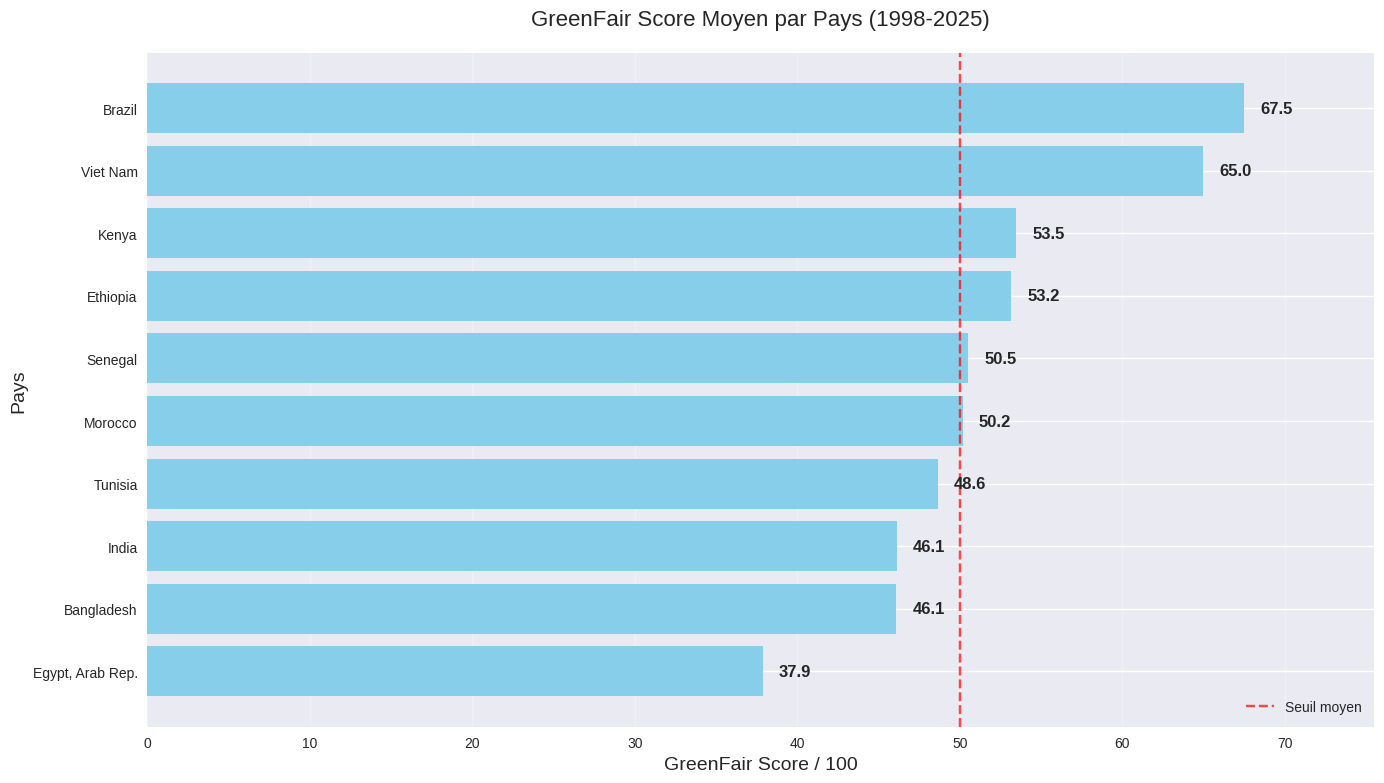

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration générale
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# ===================== 1. SCORE GLOBAL PAR PAYS =====================

# Période dynamique
annee_min = int(df_scores['annee'].min())
annee_max = int(df_scores['annee'].max())

# Score moyen par pays
scores_moyens = (
    df_scores
    .groupby('pays')['greenfair_score']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(14, 8))

bars = plt.barh(
    scores_moyens.index,
    scores_moyens.values,
    color='skyblue'
)

plt.title(
    f'GreenFair Score Moyen par Pays ({annee_min}-{annee_max})',
    fontsize=16,
    pad=20
)
plt.xlabel('GreenFair Score / 100', fontsize=14)
plt.ylabel('Pays', fontsize=14)

# Axe borné de 0 à 100, avec marge pour les labels
plt.xlim(0, min(105, max(scores_moyens.max() + 8, 60)))

# Ajouter les valeurs sur les barres
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}',
        va='center',
        fontsize=12,
        fontweight='bold'
    )

plt.axvline(
    x=50,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Seuil moyen'
)

plt.legend()
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


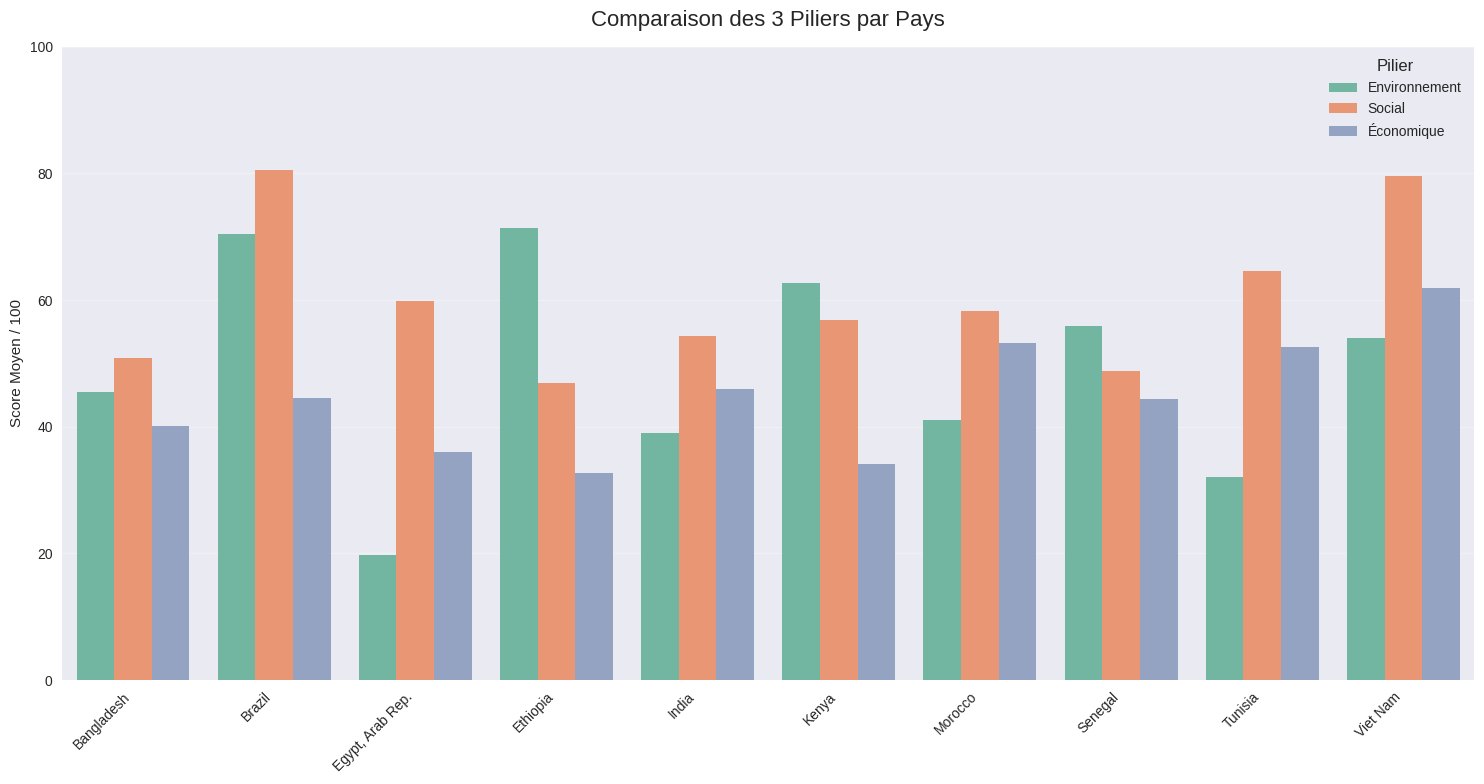

In [ ]:
# ===================== COMPARAISON DES 3 PILIERS PAR PAYS =====================

# Préparation des données
pillar_melt = (
    df_scores
    .groupby('pays')[['score_env', 'score_social', 'score_eco']]
    .mean()
    .mul(100)
    .reset_index()
)

pillar_melt = pillar_melt.melt(
    id_vars='pays',
    var_name='Pilier',
    value_name='Score'
)

# Renommer les piliers pour l'affichage
pillar_melt['Pilier'] = pillar_melt['Pilier'].replace({
    'score_env': 'Environnement',
    'score_social': 'Social',
    'score_eco': 'Économique'
})

plt.figure(figsize=(15, 8))

sns.barplot(
    data=pillar_melt,
    x='pays',
    y='Score',
    hue='Pilier',
    palette='Set2'
)

plt.title('Comparaison des 3 Piliers par Pays', fontsize=16, pad=15)
plt.xlabel('')
plt.ylabel('Score Moyen / 100')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Pilier')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


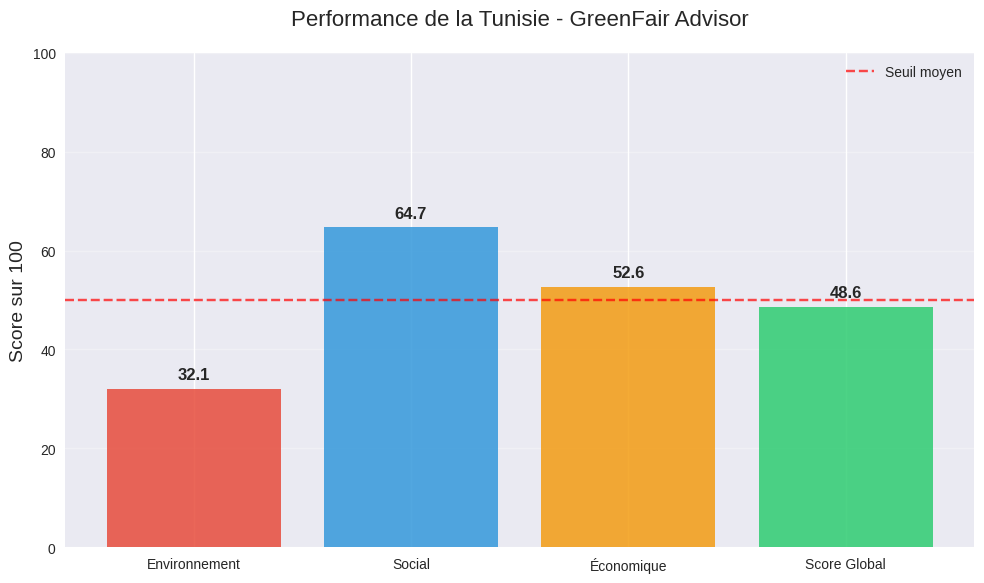

In [ ]:
# === GRAPHIQUE TUNISIE - VERSION CORRIGÉE ET CLAIRE ===

import matplotlib.pyplot as plt

# Données Tunisie
tunisia_df = df_scores[
    df_scores['pays'].str.contains('Tunisia', case=False, na=False)
]

if tunisia_df.empty:
    print("⚠️ Aucune donnée trouvée pour la Tunisie.")
    print("Pays disponibles :", df_scores['pays'].unique())
else:
    # Moyennes des piliers converties en /100
    tunisia_means = tunisia_df[['score_env', 'score_social', 'score_eco']].mean() * 100
    global_score = tunisia_df['greenfair_score'].mean()

    categories = ['Environnement', 'Social', 'Économique', 'Score Global']
    values = [
        tunisia_means['score_env'],
        tunisia_means['score_social'],
        tunisia_means['score_eco'],
        global_score
    ]

    colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        categories,
        values,
        color=colors,
        alpha=0.85
    )

    plt.title('Performance de la Tunisie - GreenFair Advisor', fontsize=16, pad=20)
    plt.ylabel('Score sur 100', fontsize=14)
    plt.ylim(0, 100)

    # Afficher les valeurs sur toutes les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            min(height + 2, 98),
            f'{height:.1f}',
            ha='center',
            fontsize=12,
            fontweight='bold'
        )

    plt.axhline(
        y=50,
        color='red',
        linestyle='--',
        alpha=0.7,
        label='Seuil moyen'
    )

    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


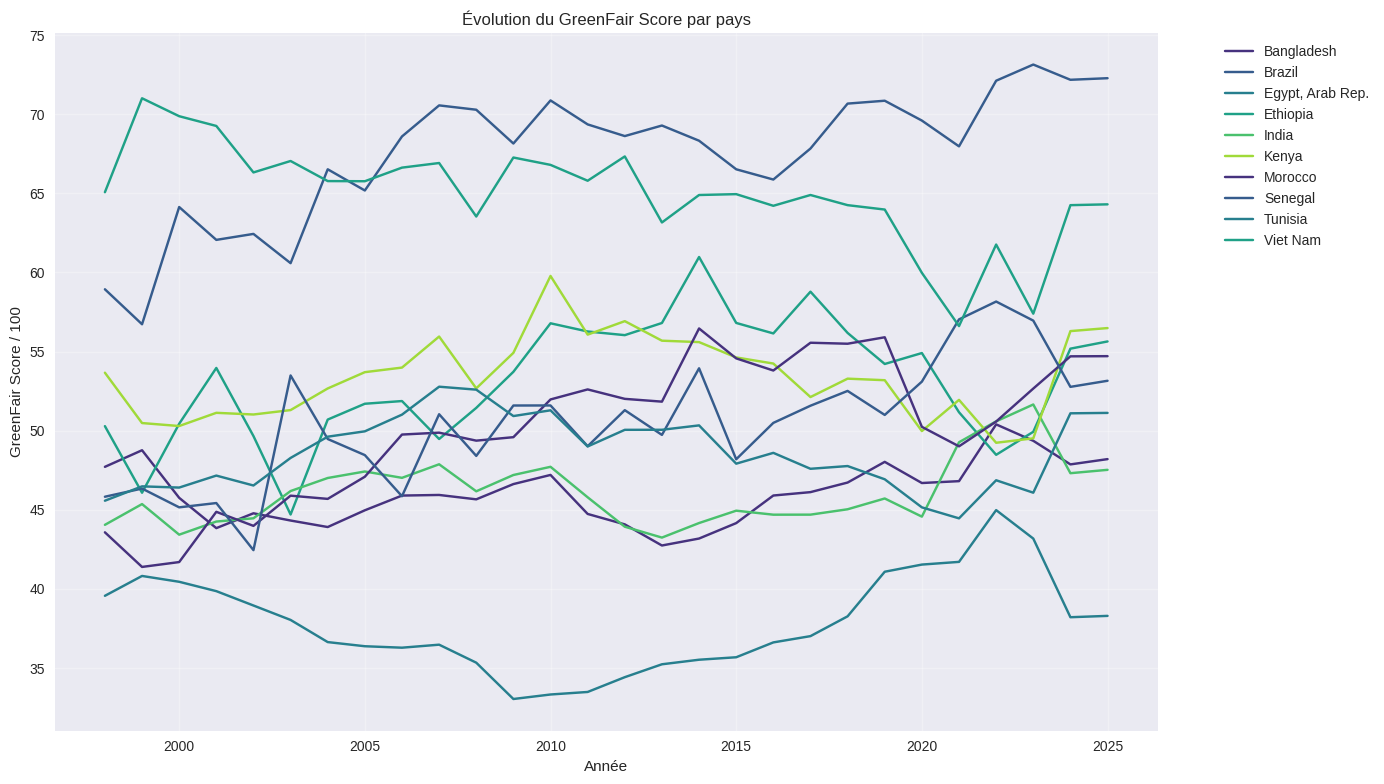

In [ ]:
# Évolution du GreenFair Score dans le temps
plt.figure(figsize=(14, 8))

for pays in df_scores['pays'].unique():
    subset = df_scores[df_scores['pays'] == pays]
    plt.plot(subset['annee'], subset['greenfair_score'], label=pays)

plt.title('Évolution du GreenFair Score par pays')
plt.xlabel('Année')
plt.ylabel('GreenFair Score / 100')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


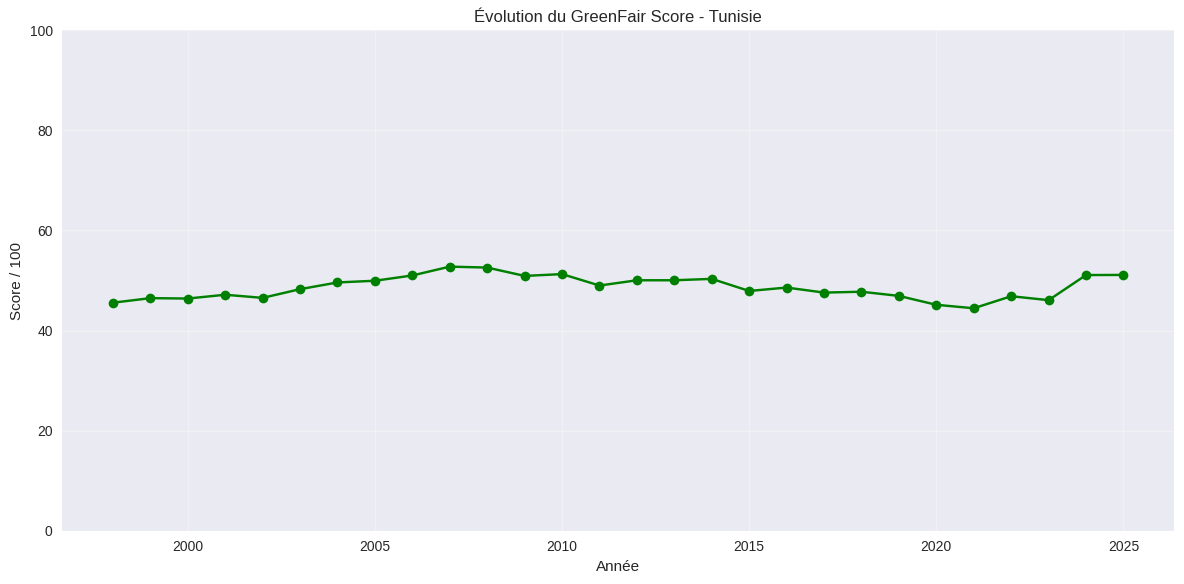

In [ ]:
tunisia_df = df_scores[df_scores['pays'].str.contains('Tunisia', case=False, na=False)]

plt.figure(figsize=(12, 6))
plt.plot(tunisia_df['annee'], tunisia_df['greenfair_score'], marker='o', color='green')

plt.title('Évolution du GreenFair Score - Tunisie')
plt.xlabel('Année')
plt.ylabel('Score / 100')
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
ranking = (
    df_scores.groupby('pays')['greenfair_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("🏆 Classement moyen des pays :")
print(ranking.to_string(index=False))


🏆 Classement moyen des pays :
            pays  greenfair_score
          Brazil        67.482235
        Viet Nam        64.960262
           Kenya        53.452765
        Ethiopia        53.151888
         Senegal        50.498290
         Morocco        50.171767
         Tunisia        48.627023
           India        46.114463
      Bangladesh        46.082633
Egypt, Arab Rep.        37.870421


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df_scores[['score_env', 'score_social', 'score_eco']]
y = df_scores['greenfair_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² :", round(r2_score(y_test, y_pred), 3))
print("MSE :", round(mean_squared_error(y_test, y_pred), 3))


R² : 1.0
MSE : 0.0


In [ ]:
def recommander(row):
    scores = {
        'environnement': row['score_env'],
        'social': row['score_social'],
        'economie': row['score_eco']
    }

    faiblesse = min(scores, key=scores.get)

    if faiblesse == 'environnement':
        return "Renforcer les politiques climatiques, réduire la pollution et développer les énergies renouvelables."
    elif faiblesse == 'social':
        return "Investir dans l’éducation, la santé, l’emploi et l’inclusion sociale."
    else:
        return "Améliorer la croissance durable, l’investissement productif et la stabilité économique."

df_scores['recommandation'] = df_scores.apply(recommander, axis=1)

print(df_scores[['pays', 'annee', 'greenfair_score', 'recommandation']].head())


pilier        pays  annee  greenfair_score  \
0       Bangladesh   1998        47.712242   
1       Bangladesh   1999        48.760929   
2       Bangladesh   2000        45.754035   
3       Bangladesh   2001        43.839081   
4       Bangladesh   2002        44.776989   

pilier                                     recommandation  
0       Améliorer la croissance durable, l’investissem...  
1       Améliorer la croissance durable, l’investissem...  
2       Améliorer la croissance durable, l’investissem...  
3       Investir dans l’éducation, la santé, l’emploi ...  
4       Améliorer la croissance durable, l’investissem...  


# Phase 5 : premier Model : regression linéaire

Modele 1 : Regression lineaire avec 80% training et 20% test
Objectif : predire le GreenFair Score a partir des trois piliers : environnement, social et economie.

Ce premier modele est volontairement simple et interpretable. Il sert de modele de base pour montrer la demarche ML : separation des donnees, entrainement, prediction et evaluation.

Remarque importante : comme le GreenFair Score est calcule directement a partir des trois piliers, cette regression lineaire aura normalement une tres bonne performance. Elle est donc utile pour valider la logique du score, mais pas encore pour faire une vraie prevision temporelle.

Valeurs manquantes avant nettoyage :
pilier
score_env          0
score_social       0
score_eco          0
greenfair_score    0
dtype: int64

Lignes supprimees a cause des NaN : 0
Taille totale du dataset ML propre : 280

Training set 80% : 224 observations
Test set 20%     : 56 observations

=== PERFORMANCE DU MODELE : REGRESSION LINEAIRE ===
MAE  : 0.0000
RMSE : 0.0000
R2   : 1.0000

=== COEFFICIENTS DU MODELE ===
    Variable  Coefficient
   score_env         40.0
score_social         35.0
   score_eco         25.0
Intercept : -0.0000

=== EXEMPLES DE PREDICTIONS SUR LE TEST SET ===
 score_env  score_social  score_eco  score_reel  score_predit  erreur_absolue
     0.717         0.726      0.260      60.582        60.582             0.0
     0.598         0.517      0.258      48.472        48.472             0.0
     0.303         0.692      0.560      50.331        50.331             0.0
     0.623         0.752      0.581      65.760        65.760             0.0
     0.652       

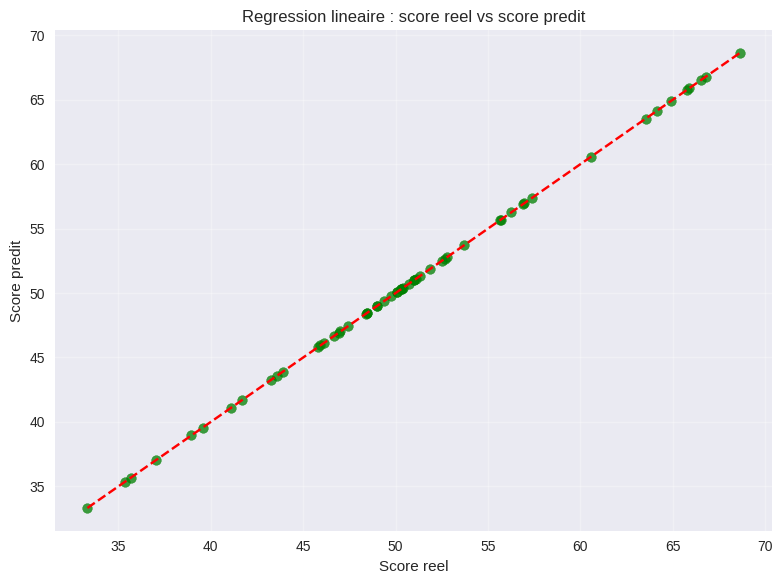

In [ ]:
# === MODELE 1 : REGRESSION LINEAIRE AVEC SPLIT 80% / 20% ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Creation d'un dataset ML propre
# LinearRegression n'accepte pas les valeurs NaN.
# On garde seulement les lignes ou les 3 piliers et le score global sont disponibles.
colonnes_ml = ['score_env', 'score_social', 'score_eco', 'greenfair_score']

df_ml = df_scores[colonnes_ml].copy()
print('Valeurs manquantes avant nettoyage :')
print(df_ml.isna().sum())

n_avant = len(df_ml)
df_ml = df_ml.dropna(subset=colonnes_ml)
n_apres = len(df_ml)

print('\nLignes supprimees a cause des NaN :', n_avant - n_apres)
print('Taille totale du dataset ML propre :', n_apres)

# 2. Variables explicatives et variable cible
# Les trois piliers expliquent le GreenFair Score.
X = df_ml[['score_env', 'score_social', 'score_eco']]
y = df_ml['greenfair_score']

# 3. Separation des donnees : 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.80,
    test_size=0.20,
    random_state=42
)

print('\nTraining set 80% :', len(X_train), 'observations')
print('Test set 20%     :', len(X_test), 'observations')

# 4. Entrainement du modele
modele_lr = LinearRegression()
modele_lr.fit(X_train, y_train)

# 5. Prediction sur le test set
y_pred = modele_lr.predict(X_test)

# 6. Evaluation du modele
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('\n=== PERFORMANCE DU MODELE : REGRESSION LINEAIRE ===')
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')

# 7. Coefficients du modele
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': modele_lr.coef_
})

print('\n=== COEFFICIENTS DU MODELE ===')
print(coefficients.round(4).to_string(index=False))
print(f'Intercept : {modele_lr.intercept_:.4f}')

# 8. Tableau de comparaison reel vs predit
resultats_lr = X_test.copy()
resultats_lr['score_reel'] = y_test.values
resultats_lr['score_predit'] = y_pred
resultats_lr['erreur_absolue'] = abs(resultats_lr['score_reel'] - resultats_lr['score_predit'])

print('\n=== EXEMPLES DE PREDICTIONS SUR LE TEST SET ===')
print(resultats_lr.round(3).head(10).to_string(index=False))

# 9. Visualisation : score reel vs score predit
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.75, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Score reel')
plt.ylabel('Score predit')
plt.title('Regression lineaire : score reel vs score predit')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# === MODELE 2 : RIDGE TEMPORELLE POUR VISION STRATEGIQUE ===
# Objectif : predire le GreenFair Score de l'annee suivante.
# Pourquoi ce modele ?
# - Dataset limite : environ 10 pays x plusieurs annees.
# - Besoin strategique : un modele interpretable vaut mieux qu'un modele complexe.
# - Evite la fuite de cible : on ne predit pas le score avec sa formule directe.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Annee maximale consideree comme reelle dans la recuperation World Bank initiale.
# Les annees 2024 et 2025 ont ete ajoutees par extrapolation simple dans le notebook.
ANNEE_DONNEES_REELLES_MAX = 2023

# -----------------------------
# 1. Preparation du dataset ML
# -----------------------------
ml_df = df_scores.copy()
ml_df['annee'] = pd.to_numeric(ml_df['annee'], errors='coerce').astype(int)
ml_df = ml_df.sort_values(['pays', 'annee']).reset_index(drop=True)

# Les scores de pilier sont stockes sur [0, 1], on les convertit en /100 pour la lisibilite.
ml_df['score_env_100'] = ml_df['score_env'] * 100
ml_df['score_social_100'] = ml_df['score_social'] * 100
ml_df['score_eco_100'] = ml_df['score_eco'] * 100

# Variables de tendance : utiles pour anticiper une trajectoire, pas seulement photographier l'etat actuel.
ml_df['greenfair_lag1'] = ml_df.groupby('pays')['greenfair_score'].shift(1)
ml_df['delta_1y'] = ml_df.groupby('pays')['greenfair_score'].diff(1)
ml_df['delta_3y'] = ml_df.groupby('pays')['greenfair_score'].diff(3)
ml_df['rolling_3y_score'] = (
    ml_df.groupby('pays')['greenfair_score']
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

# Gaps strategiques : plus le gap est grand, plus le pilier a besoin d'attention.
ml_df['gap_env'] = 100 - ml_df['score_env_100']
ml_df['gap_social'] = 100 - ml_df['score_social_100']
ml_df['gap_eco'] = 100 - ml_df['score_eco_100']

# Cible : score de l'annee suivante pour le meme pays.
ml_df['target_next_score'] = ml_df.groupby('pays')['greenfair_score'].shift(-1)
ml_df['target_year'] = ml_df.groupby('pays')['annee'].shift(-1)

model_data = ml_df.dropna(subset=['target_next_score', 'target_year']).copy()
model_data['target_year'] = model_data['target_year'].astype(int)

# Evaluation honnete : on evalue seulement sur les annees reelles, pas sur les annees extrapolees.
model_data_real = model_data[model_data['target_year'] <= ANNEE_DONNEES_REELLES_MAX].copy()

numeric_features = [
    'annee',
    'greenfair_score',
    'score_env_100',
    'score_social_100',
    'score_eco_100',
    'greenfair_lag1',
    'delta_1y',
    'delta_3y',
    'rolling_3y_score',
    'gap_env',
    'gap_social',
    'gap_eco'
]
categorical_features = ['pays']
feature_cols = numeric_features + categorical_features
target_col = 'target_next_score'

# Split temporel : les dernieres annees reelles servent de test.
test_years = sorted(model_data_real['target_year'].unique())[-4:]
train_data = model_data_real[~model_data_real['target_year'].isin(test_years)].copy()
test_data = model_data_real[model_data_real['target_year'].isin(test_years)].copy()

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', one_hot)
        ]), categorical_features)
    ],
    remainder='drop',
    sparse_threshold=0
)

ridge_model = Pipeline([
    ('preprocess', preprocess),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 13)))
])

ridge_model.fit(train_data[feature_cols], train_data[target_col])
y_pred = ridge_model.predict(test_data[feature_cols])

# Baseline naive : le score de l'annee prochaine = score actuel.
baseline_pred = test_data['greenfair_score'].values

def regression_report(y_true, y_hat):
    return {
        'MAE': mean_absolute_error(y_true, y_hat),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_hat)),
        'R2': r2_score(y_true, y_hat)
    }

metrics_model = regression_report(test_data[target_col], y_pred)
metrics_baseline = regression_report(test_data[target_col], baseline_pred)

print('Objectif ML : predire le GreenFair Score de l annee suivante')
print(f'Periode train : {train_data["annee"].min()}-{train_data["target_year"].max()}')
print(f'Annees test   : {test_years}')
print(f'Modele retenu : Ridge Regression | alpha = {ridge_model.named_steps["model"].alpha_:.4f}')

results_metrics = pd.DataFrame([
    {'approche': 'Baseline naive', **metrics_baseline},
    {'approche': 'Ridge temporelle', **metrics_model}
]).round(3)

print('\nPerformance sur les dernieres annees reelles :')
print(results_metrics.to_string(index=False))

comparison = test_data[['pays', 'annee', 'target_year', 'greenfair_score', 'target_next_score']].copy()
comparison['prediction_ridge'] = y_pred
comparison['erreur_absolue'] = (comparison['target_next_score'] - comparison['prediction_ridge']).abs()
comparison = comparison.round(2).sort_values(['target_year', 'erreur_absolue'])

print('\nExemples de predictions sur la periode test :')
print(comparison.head(12).to_string(index=False))


Objectif ML : predire le GreenFair Score de l annee suivante
Periode train : 1998-2019
Annees test   : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Modele retenu : Ridge Regression | alpha = 1.0000

Performance sur les dernieres annees reelles :
        approche   MAE  RMSE    R2
  Baseline naive 2.157 2.599 0.888
Ridge temporelle 2.336 2.852 0.865

Exemples de predictions sur la periode test :
            pays  annee  target_year  greenfair_score  target_next_score  prediction_ridge  erreur_absolue
      Bangladesh   2019         2020            48.03              46.69             46.94            0.25
        Ethiopia   2019         2020            54.21              54.90             55.64            0.73
          Brazil   2019         2020            70.85              69.59             70.76            1.17
           India   2019         2020            45.71              44.57             45.89            1.32
         Senegal   2019         2020           

In [ ]:
# === VISION STRATEGIQUE : PREVISION ET PRIORITES PAR PAYS ===

# On reentraine le modele sur toute la periode reelle disponible, puis on applique le modele
# au dernier etat disponible du notebook. Si 2025 est present, il s'agit d'un scenario extrapole.
final_model = Pipeline([
    ('preprocess', preprocess),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 13)))
])
final_model.fit(model_data_real[feature_cols], model_data_real[target_col])

latest_rows = (
    ml_df.sort_values(['pays', 'annee'])
    .groupby('pays', as_index=False)
    .tail(1)
    .copy()
)

latest_rows['score_prevu_next_year'] = final_model.predict(latest_rows[feature_cols])
latest_rows['score_prevu_next_year'] = latest_rows['score_prevu_next_year'].clip(0, 100)
latest_rows['annee_prevue'] = latest_rows['annee'] + 1
latest_rows['variation_prevue'] = latest_rows['score_prevu_next_year'] - latest_rows['greenfair_score']
latest_rows['source_projection'] = np.where(
    latest_rows['annee'] > ANNEE_DONNEES_REELLES_MAX,
    'scenario_extrapole',
    'donnee_reelle'
)

def pilier_faible(row):
    scores = {
        'Environnement': row['score_env_100'],
        'Social': row['score_social_100'],
        'Economique': row['score_eco_100']
    }
    return min(scores, key=scores.get)

def niveau_strategique(score):
    if score >= 70:
        return 'Leader durable'
    if score >= 55:
        return 'Potentiel solide'
    if score >= 40:
        return 'Transition fragile'
    return 'Priorite critique'

def recommandation_strategique(row):
    pilier = row['pilier_faible']
    variation = row['variation_prevue']
    score_prevu = row['score_prevu_next_year']

    if pilier == 'Environnement':
        action = 'prioriser energie renouvelable, qualite de l air, CO2 et protection des espaces naturels'
    elif pilier == 'Social':
        action = 'renforcer education, sante, emploi et inclusion sociale'
    else:
        action = 'stabiliser inflation, stimuler investissement productif, exportations et croissance durable'

    if score_prevu < 50:
        posture = 'redressement rapide'
    elif variation < -1:
        posture = 'prevention du recul'
    elif variation > 1:
        posture = 'acceleration selective'
    else:
        posture = 'consolidation'

    return f'{posture} : {action}'

latest_rows['pilier_faible'] = latest_rows.apply(pilier_faible, axis=1)
latest_rows['niveau_prevu'] = latest_rows['score_prevu_next_year'].apply(niveau_strategique)
latest_rows['recommandation_strategique'] = latest_rows.apply(recommandation_strategique, axis=1)

strategic_view = latest_rows[[
    'pays',
    'annee',
    'annee_prevue',
    'greenfair_score',
    'score_prevu_next_year',
    'variation_prevue',
    'niveau_prevu',
    'pilier_faible',
    'source_projection',
    'recommandation_strategique'
]].copy()

strategic_view = strategic_view.rename(columns={
    'annee': 'annee_reference',
    'greenfair_score': 'score_actuel',
    'score_prevu_next_year': 'score_prevu'
})

strategic_view = strategic_view.round({
    'score_actuel': 2,
    'score_prevu': 2,
    'variation_prevue': 2
}).sort_values('score_prevu', ascending=False)

print('Vision strategique par pays')
print(strategic_view.to_string(index=False))

# Sauvegarde pour reutilisation dans un rapport ou dashboard.
strategic_view.to_csv('greenfair_predictions_strategy.csv', index=False)
print('\nFichier exporte : greenfair_predictions_strategy.csv')


Vision strategique par pays
            pays  annee_reference  annee_prevue  score_actuel  score_prevu  variation_prevue       niveau_prevu pilier_faible  source_projection                                                                                        recommandation_strategique
          Brazil             2025          2026         72.27        72.74              0.47     Leader durable    Economique scenario_extrapole       consolidation : stabiliser inflation, stimuler investissement productif, exportations et croissance durable
        Viet Nam             2025          2026         64.30        63.04             -1.26   Potentiel solide Environnement scenario_extrapole    prevention du recul : prioriser energie renouvelable, qualite de l air, CO2 et protection des espaces naturels
           Kenya             2025          2026         56.48        55.13             -1.36   Potentiel solide    Economique scenario_extrapole prevention du recul : stabiliser inflation, stimul

In [ ]:
# === VISION STRATEGIQUE : PREVISION ET PRIORITES PAR PAYS ===

# On reentraine le modele sur toute la periode reelle disponible, puis on applique le modele
# au dernier etat disponible du notebook. Si 2025 est present, il s'agit d'un scenario extrapole.
final_model = Pipeline([
    ('preprocess', preprocess),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 13)))
])
final_model.fit(model_data_real[feature_cols], model_data_real[target_col])

latest_rows = (
    ml_df.sort_values(['pays', 'annee'])
    .groupby('pays', as_index=False)
    .tail(1)
    .copy()
)

latest_rows['score_prevu_next_year'] = final_model.predict(latest_rows[feature_cols])
latest_rows['score_prevu_next_year'] = latest_rows['score_prevu_next_year'].clip(0, 100)
latest_rows['annee_prevue'] = latest_rows['annee'] + 1
latest_rows['variation_prevue'] = latest_rows['score_prevu_next_year'] - latest_rows['greenfair_score']
latest_rows['source_projection'] = np.where(
    latest_rows['annee'] > ANNEE_DONNEES_REELLES_MAX,
    'scenario_extrapole',
    'donnee_reelle'
)

def pilier_faible(row):
    scores = {
        'Environnement': row['score_env_100'],
        'Social': row['score_social_100'],
        'Economique': row['score_eco_100']
    }
    return min(scores, key=scores.get)

def niveau_strategique(score):
    if score >= 70:
        return 'Leader durable'
    if score >= 55:
        return 'Potentiel solide'
    if score >= 40:
        return 'Transition fragile'
    return 'Priorite critique'

def recommandation_strategique(row):
    pilier = row['pilier_faible']
    variation = row['variation_prevue']
    score_prevu = row['score_prevu_next_year']

    if pilier == 'Environnement':
        action = 'prioriser energie renouvelable, qualite de l air, CO2 et protection des espaces naturels'
    elif pilier == 'Social':
        action = 'renforcer education, sante, emploi et inclusion sociale'
    else:
        action = 'stabiliser inflation, stimuler investissement productif, exportations et croissance durable'

    if score_prevu < 50:
        posture = 'redressement rapide'
    elif variation < -1:
        posture = 'prevention du recul'
    elif variation > 1:
        posture = 'acceleration selective'
    else:
        posture = 'consolidation'

    return f'{posture} : {action}'

latest_rows['pilier_faible'] = latest_rows.apply(pilier_faible, axis=1)
latest_rows['niveau_prevu'] = latest_rows['score_prevu_next_year'].apply(niveau_strategique)
latest_rows['recommandation_strategique'] = latest_rows.apply(recommandation_strategique, axis=1)

strategic_view = latest_rows[[
    'pays',
    'annee',
    'annee_prevue',
    'greenfair_score',
    'score_prevu_next_year',
    'variation_prevue',
    'niveau_prevu',
    'pilier_faible',
    'source_projection',
    'recommandation_strategique'
]].copy()

strategic_view = strategic_view.rename(columns={
    'annee': 'annee_reference',
    'greenfair_score': 'score_actuel',
    'score_prevu_next_year': 'score_prevu'
})

strategic_view = strategic_view.round({
    'score_actuel': 2,
    'score_prevu': 2,
    'variation_prevue': 2
}).sort_values('score_prevu', ascending=False)

print('Vision strategique par pays')
print(strategic_view.to_string(index=False))

# Sauvegarde pour reutilisation dans un rapport ou dashboard.
strategic_view.to_csv('greenfair_predictions_strategy.csv', index=False)
print('\nFichier exporte : greenfair_predictions_strategy.csv')


Vision strategique par pays
            pays  annee_reference  annee_prevue  score_actuel  score_prevu  variation_prevue       niveau_prevu pilier_faible  source_projection                                                                                        recommandation_strategique
          Brazil             2025          2026         72.27        72.74              0.47     Leader durable    Economique scenario_extrapole       consolidation : stabiliser inflation, stimuler investissement productif, exportations et croissance durable
        Viet Nam             2025          2026         64.30        63.04             -1.26   Potentiel solide Environnement scenario_extrapole    prevention du recul : prioriser energie renouvelable, qualite de l air, CO2 et protection des espaces naturels
           Kenya             2025          2026         56.48        55.13             -1.36   Potentiel solide    Economique scenario_extrapole prevention du recul : stabiliser inflation, stimul

Variables les plus influentes dans la prevision :
        variable  coefficient
 greenfair_score        2.490
   score_env_100        2.204
         gap_env       -2.204
      gap_social       -1.243
score_social_100        1.243
         gap_eco       -0.596
   score_eco_100        0.596
rolling_3y_score        0.496
        delta_3y       -0.257
        delta_1y       -0.252
           annee        0.235
  greenfair_lag1       -0.049


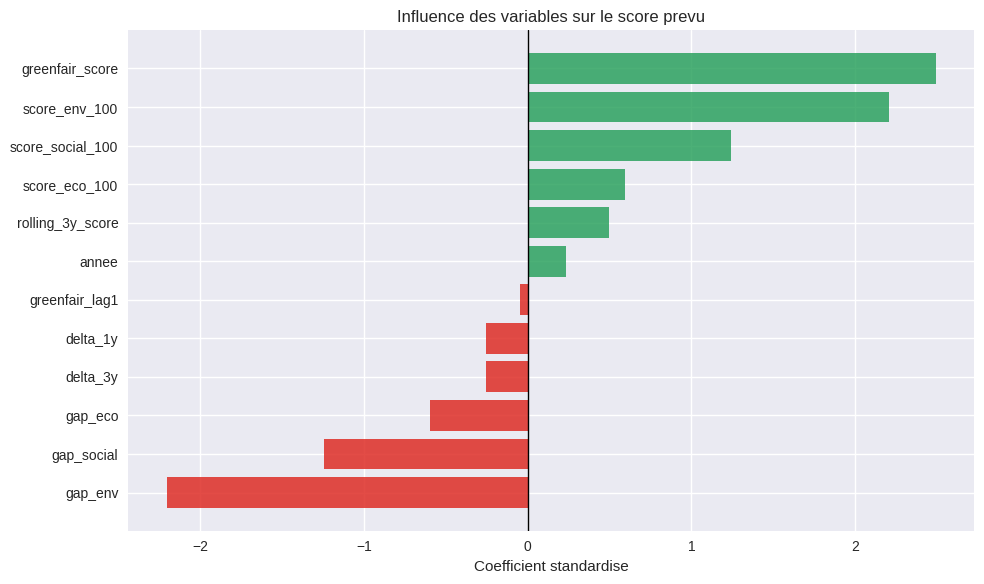


FOCUS TUNISIE - LECTURE STRATEGIQUE
Annee de reference : 2025 (scenario_extrapole)
Score actuel       : 51.12/100
Score prevu        : 50.79/100 en 2026
Variation prevue   : -0.33 points
Niveau prevu       : Transition fragile
Pilier faible      : Environnement
Action prioritaire : consolidation : prioriser energie renouvelable, qualite de l air, CO2 et protection des espaces naturels


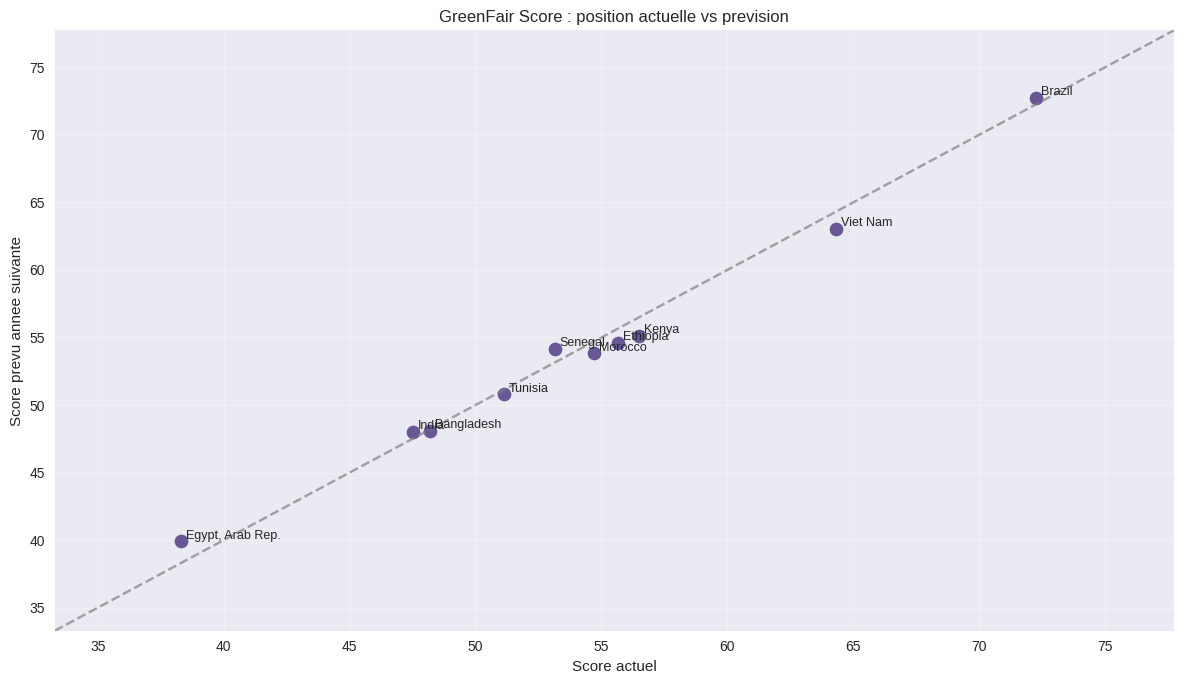

In [ ]:
# === INTERPRETATION DU MODELE ET FOCUS TUNISIE ===

# Importance des variables numeriques : avec Ridge + StandardScaler,
# les coefficients numeriques sont comparables entre eux.
preprocessor_fitted = final_model.named_steps['preprocess']
ridge_fitted = final_model.named_steps['model']

try:
    cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
    cat_names = cat_encoder.get_feature_names_out(categorical_features)
except AttributeError:
    cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
    cat_names = cat_encoder.get_feature_names(categorical_features)

feature_names = numeric_features + list(cat_names)
coef_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': ridge_fitted.coef_
})

coef_numeric = coef_df[coef_df['variable'].isin(numeric_features)].copy()
coef_numeric['impact_abs'] = coef_numeric['coefficient'].abs()
coef_numeric = coef_numeric.sort_values('impact_abs', ascending=False)

print('Variables les plus influentes dans la prevision :')
print(coef_numeric[['variable', 'coefficient']].round(3).to_string(index=False))

# Visualisation simple des coefficients numeriques.
plt.figure(figsize=(10, 6))
plot_df = coef_numeric.sort_values('coefficient')
colors = np.where(plot_df['coefficient'] >= 0, '#2ca25f', '#de2d26')
plt.barh(plot_df['variable'], plot_df['coefficient'], color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=1)
plt.title('Influence des variables sur le score prevu')
plt.xlabel('Coefficient standardise')
plt.tight_layout()
plt.show()

# Focus Tunisie
focus_tunisie = strategic_view[
    strategic_view['pays'].str.contains('Tunisia', case=False, na=False)
]

if focus_tunisie.empty:
    print('\nTunisie introuvable dans les predictions.')
else:
    t = focus_tunisie.iloc[0]
    print('\nFOCUS TUNISIE - LECTURE STRATEGIQUE')
    print(f"Annee de reference : {int(t['annee_reference'])} ({t['source_projection']})")
    print(f"Score actuel       : {t['score_actuel']:.2f}/100")
    print(f"Score prevu        : {t['score_prevu']:.2f}/100 en {int(t['annee_prevue'])}")
    print(f"Variation prevue   : {t['variation_prevue']:+.2f} points")
    print(f"Niveau prevu       : {t['niveau_prevu']}")
    print(f"Pilier faible      : {t['pilier_faible']}")
    print(f"Action prioritaire : {t['recommandation_strategique']}")

# Graphique actuel vs prevu
plt.figure(figsize=(12, 7))
plot_strategy = strategic_view.sort_values('score_prevu')
plt.scatter(plot_strategy['score_actuel'], plot_strategy['score_prevu'], s=90, alpha=0.8)

for _, row in plot_strategy.iterrows():
    plt.text(row['score_actuel'] + 0.2, row['score_prevu'] + 0.2, row['pays'], fontsize=9)

min_axis = max(0, min(plot_strategy['score_actuel'].min(), plot_strategy['score_prevu'].min()) - 5)
max_axis = min(100, max(plot_strategy['score_actuel'].max(), plot_strategy['score_prevu'].max()) + 5)
plt.plot([min_axis, max_axis], [min_axis, max_axis], '--', color='gray', alpha=0.7)
plt.xlim(min_axis, max_axis)
plt.ylim(min_axis, max_axis)
plt.xlabel('Score actuel')
plt.ylabel('Score prevu annee suivante')
plt.title('GreenFair Score : position actuelle vs prevision')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#Phase 6 : Modele ML non supervise - Clustering
Modele 2 : K-Means Clustering avec metriques
Objectif : regrouper les pays selon leur profil GreenFair moyen : environnement, social, economie et score global.

Ce modele ne predit pas une valeur. Il sert a identifier des groupes de pays ayant des profils similaires, ce qui aide a comparer la Tunisie avec des pays proches et a definir une strategie adaptee.

Nombre de pays utilises pour le clustering : 10

Profil moyen par pays :
pilier            score_env_100  score_social_100  score_eco_100  greenfair_score
pays                                                                             
Bangladesh               45.567            50.914         40.144           46.083
Brazil                   70.475            80.501         44.467           67.482
Egypt, Arab Rep.         19.811            59.854         35.988           37.870
Ethiopia                 71.424            46.927         32.632           53.152
India                    38.972            54.381         45.969           46.114
Kenya                    62.644            56.785         34.081           53.453
Morocco                  41.106            58.351         53.226           50.172
Senegal                  55.876            48.745         44.348           50.498
Tunisia                  32.095            64.676         52.610           48.627
Viet Nam                 

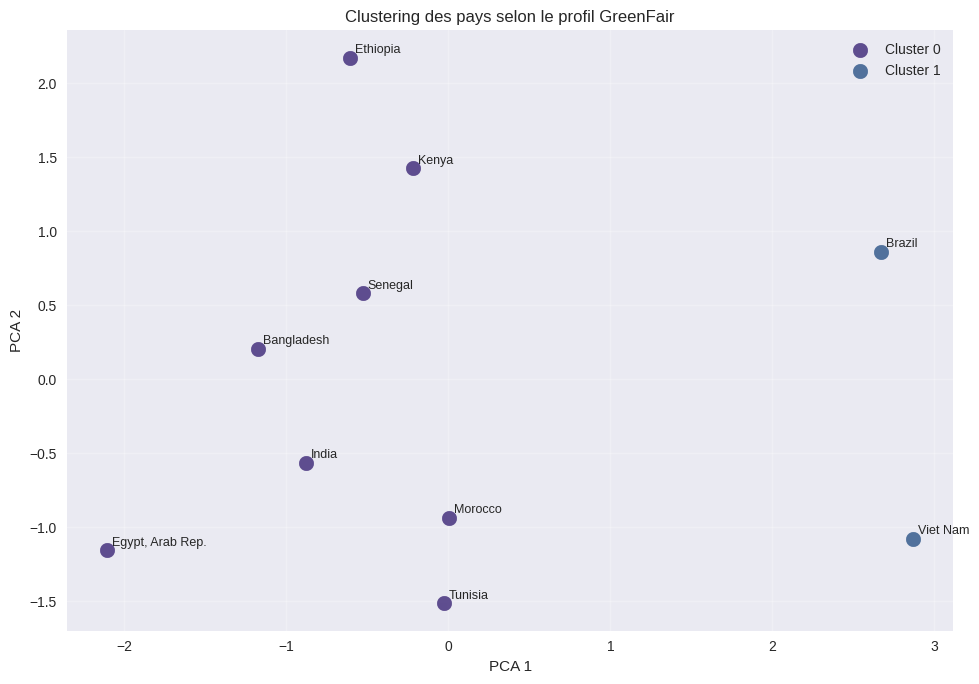

In [ ]:
# === MODELE 2 : CLUSTERING STRATEGIQUE AVEC K-MEANS ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# 1. Profil moyen par pays
cluster_base = df_scores.copy()
cluster_base['score_env_100'] = cluster_base['score_env'] * 100
cluster_base['score_social_100'] = cluster_base['score_social'] * 100
cluster_base['score_eco_100'] = cluster_base['score_eco'] * 100

features_cluster = ['score_env_100', 'score_social_100', 'score_eco_100', 'greenfair_score']

country_profiles = (
    cluster_base
    .groupby('pays')[features_cluster]
    .mean()
    .dropna()
    .round(3)
)

print('Nombre de pays utilises pour le clustering :', len(country_profiles))
print('\nProfil moyen par pays :')
print(country_profiles.to_string())

# 2. Standardisation des variables
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(country_profiles[features_cluster])

# 3. Evaluation de plusieurs valeurs de k
max_k = min(6, len(country_profiles) - 1)
cluster_metrics_rows = []

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    cluster_metrics_rows.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_cluster_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_cluster_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_cluster_scaled, labels)
    })

cluster_metrics = pd.DataFrame(cluster_metrics_rows).round(4)

print('\n=== METRIQUES CLUSTERING ===')
print(cluster_metrics.to_string(index=False))

# Regle simple : choisir le k avec le meilleur score silhouette.
best_k = int(cluster_metrics.sort_values('silhouette', ascending=False).iloc[0]['k'])
print(f'\nNombre de clusters retenu : k = {best_k}')

# 4. Modele final K-Means
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
country_profiles['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# 5. Profil moyen de chaque cluster
cluster_profiles = (
    country_profiles
    .groupby('cluster')[features_cluster]
    .mean()
    .round(2)
)
cluster_profiles['nb_pays'] = country_profiles.groupby('cluster').size()

print('\n=== PROFIL MOYEN DES CLUSTERS ===')
print(cluster_profiles.to_string())

print('\n=== PAYS PAR CLUSTER ===')
for cluster_id in sorted(country_profiles['cluster'].unique()):
    members = country_profiles[country_profiles['cluster'] == cluster_id].index.tolist()
    print(f'Cluster {cluster_id} : {members}')

# 6. Focus Tunisie
mask_tunisie = country_profiles.index.str.contains('Tunisia', case=False, na=False)
if mask_tunisie.any():
    tunisia_cluster = int(country_profiles.loc[mask_tunisie, 'cluster'].iloc[0])
    pays_similaires = country_profiles[country_profiles['cluster'] == tunisia_cluster].index.tolist()
    print('\n=== FOCUS TUNISIE - CLUSTERING ===')
    print('Cluster de la Tunisie :', tunisia_cluster)
    print('Pays comparables dans le meme cluster :', pays_similaires)
else:
    print('\nTunisie introuvable dans country_profiles.')

# 7. Visualisation PCA des clusters
pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster_scaled)

plot_clusters = country_profiles.copy()
plot_clusters['PC1'] = coords[:, 0]
plot_clusters['PC2'] = coords[:, 1]

plt.figure(figsize=(10, 7))
for cluster_id in sorted(plot_clusters['cluster'].unique()):
    subset = plot_clusters[plot_clusters['cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'], s=110, label=f'Cluster {cluster_id}', alpha=0.85)

for pays, row in plot_clusters.iterrows():
    plt.text(row['PC1'] + 0.03, row['PC2'] + 0.03, pays, fontsize=9)

plt.title('Clustering des pays selon le profil GreenFair')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Le score de silhouette autour de 0.50 indique une séparation correcte entre les groupes. Le modèle identifie donc deux grands profils :
Cluster 0 : Bangladesh, Egypt, Ethiopia, India, Kenya, Morocco, Senegal, Tunisia
Cluster 1 : Brazil, Viet Nam
Le Cluster 1 regroupe les pays les plus performants, avec un score moyen élevé autour de 67.89/100.
Le Cluster 0 regroupe les pays en transition fragile, avec un score moyen autour de 44.40/100.

#Phase 7 : Module Predictions 2030
Projection GreenFair Score a l'horizon 2030
Objectif : projeter les scores des piliers et le score global jusqu'en 2030 pour chaque pays.

La projection est basee sur une regression lineaire temporelle pays par pays. Pour eviter de donner trop de poids aux annees extrapolees, le module utilise par defaut les donnees jusqu'a 2023 comme periode reelle de reference.

In [ ]:
# === PRÉDICTIONS 2030 AVEC RANDOM FOREST (Version adaptée à tes colonnes) ===

from sklearn.ensemble import RandomForestRegressor

print("🔮 Prédictions GreenFair 2030 en cours...")

# Utilisation des vrais noms de colonnes
features = ['score_env', 'score_social', 'score_eco']

X = df_scores[features]
y = df_scores['greenfair_score']

# Entraînement du modèle
model_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8
)
model_rf.fit(X, y)

# Prédiction sur les données les plus récentes (2025)
latest_data = df_scores[df_scores['annee'] == 2025].copy().reset_index(drop=True)

latest_data['greenfair_score_pred_2030'] = model_rf.predict(latest_data[features])

# Calcul de la variation
latest_data['variation_2030'] = latest_data['greenfair_score_pred_2030'] - latest_data['greenfair_score']

# Niveau qualitatif
def get_niveau(score):
    if score >= 70: return "Leader durable"
    elif score >= 55: return "Potentiel solide"
    elif score >= 45: return "Transition fragile"
    else: return "Priorité critique"

latest_data['niveau_2030'] = latest_data['greenfair_score_pred_2030'].apply(get_niveau)

# Résultat final
summary_2030 = latest_data.sort_values('greenfair_score_pred_2030', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("🌍 VISION STRATÉGIQUE GREENFAIR 2030")
print("="*80)
display_cols = ['pays', 'greenfair_score', 'greenfair_score_pred_2030', 'variation_2030', 'niveau_2030']
print(summary_2030[display_cols].round(2))

# Sauvegarde
summary_2030.to_csv('greenfair_predictions_2030.csv', index=False)
print("\n💾 Fichier sauvegardé : greenfair_predictions_2030.csv")

🔮 Prédictions GreenFair 2030 en cours...

🌍 VISION STRATÉGIQUE GREENFAIR 2030
pilier              pays  greenfair_score  greenfair_score_pred_2030  \
0                 Brazil            72.27                      71.98   
1               Viet Nam            64.30                      63.64   
2                  Kenya            56.48                      55.36   
3               Ethiopia            55.64                      55.35   
4                Morocco            54.71                      54.98   
5                Senegal            53.15                      52.65   
6                Tunisia            51.12                      51.27   
7                  India            47.52                      48.09   
8             Bangladesh            48.20                      47.90   
9       Egypt, Arab Rep.            38.29                      38.59   

pilier  variation_2030         niveau_2030  
0                -0.29      Leader durable  
1                -0.66    Potentiel sol

La Tunisie appartient au Cluster 0, donc elle est classée avec les pays ayant une performance GreenFair moyenne ou fragile. Son profil moyen est :

Environnement : 27.75
Social        : 65.46
Economie      : 52.02
Score global  : 47.01
Cela montre que la Tunisie n’est pas faible partout. Son pilier social est relativement solide, son économie est moyenne, mais son pilier environnemental est très faible. C’est ce pilier qui empêche la Tunisie de rejoindre le groupe des pays plus performants comme le Brésil ou le Vietnam.

Conclusion Globale
Les deux modèles sont complémentaires. La régression linéaire valide la logique du GreenFair Score et confirme que l’environnement est le pilier le plus influent. Le clustering donne une vision stratégique comparative : il montre que la Tunisie appartient encore au groupe des pays en transition fragile.

Pour améliorer sa position, la priorité stratégique de la Tunisie doit être l’environnement : énergies renouvelables, réduction du CO2, qualité de l’air, protection des ressources naturelles et politiques climatiques plus fortes. Sans amélioration environnementale, la Tunisie risque de rester dans le cluster des pays à performance moyenne/faible.

# phase 8 :  RANDOM FOREST

Taille train : 210 obs | Taille test : 40 obs
Années test  : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

  COMPARAISON DES MODELES SUR LA PERIODE TEST
               Modèle   MAE  RMSE    R²
       Baseline naïve 2.157 2.599 0.888
Ridge temporelle (M2) 2.316 2.800 0.870
  Random Forest  (M3) 2.685 3.183 0.831

→ Meilleur modèle : Baseline naïve (R² = 0.888)

Importance des features (Random Forest) :
  greenfair_score           ████████ 0.217
  rolling_3y_score          █████ 0.146
  score_social_100          █████ 0.127
  greenfair_lag1            █████ 0.126
  gap_social                ████ 0.102
  pays (encodé)             ███ 0.082
  score_env_100             ███ 0.081
  gap_env                   ███ 0.079
  gap_eco                    0.016
  score_eco_100              0.013


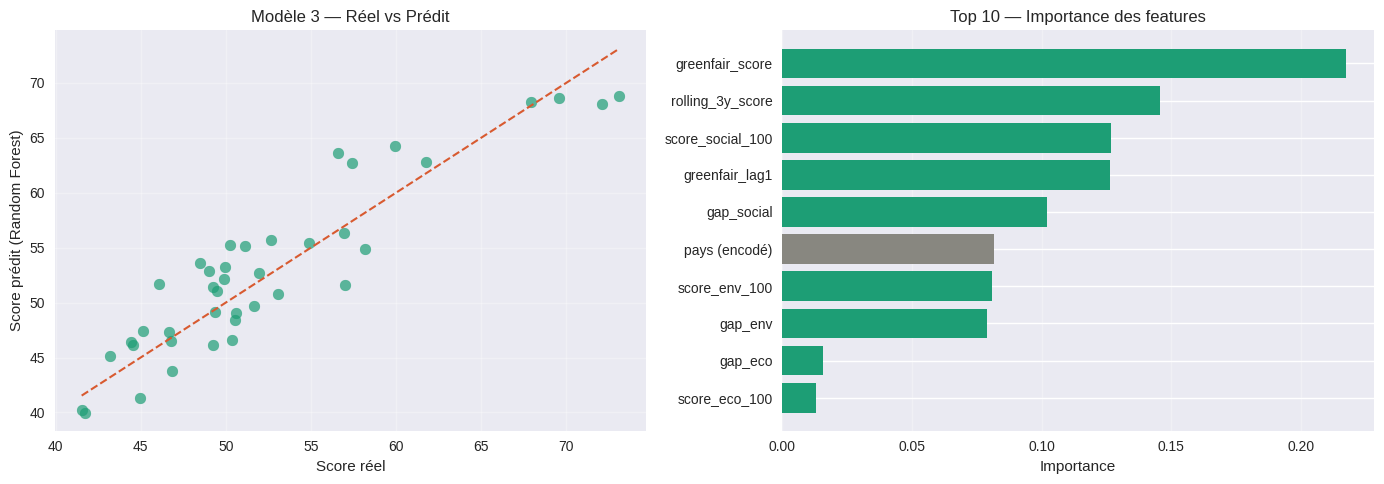


  VISION STRATEGIQUE PAR PAYS — Random Forest
            Pays  Année ref  Année prévue  Score actuel  Score prévu (RF)  Variation       Niveau prévu
          Brazil       2025          2026         72.27             69.58      -2.69   Potentiel solide
        Viet Nam       2025          2026         64.30             61.32      -2.98   Potentiel solide
         Morocco       2025          2026         54.71             55.70       1.00   Potentiel solide
           Kenya       2025          2026         56.48             54.81      -1.67 Transition fragile
        Ethiopia       2025          2026         55.64             54.05      -1.58 Transition fragile
         Tunisia       2025          2026         51.12             53.71       2.59 Transition fragile
         Senegal       2025          2026         53.15             52.37      -0.78 Transition fragile
      Bangladesh       2025          2026         48.20             48.14      -0.06 Transition fragile
           India 

In [ ]:
# ============================================================
# MODELE 3 : RANDOM FOREST — PREDICTION TEMPORELLE DU SCORE
# ============================================================
# Objectif  : prédire le GreenFair Score de l'année suivante
# Avantage  : capture les non-linéarités, résistant au bruit,
#             fournit l'importance des features
# Comparaison directe avec Modèle 1 (LinearRegression)
#             et Modèle 2 (Ridge temporelle)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# ----------------------------------------------------------
# 1. PREPARATION DU DATASET (identique au Modèle 2 pour
#    une comparaison équitable)
# ----------------------------------------------------------
ANNEE_REELLES_MAX = 2023

ml_df = df_scores.copy()
ml_df['annee'] = pd.to_numeric(ml_df['annee'], errors='coerce').astype(int)
ml_df = ml_df.sort_values(['pays', 'annee']).reset_index(drop=True)

# Scores sur /100 pour la lisibilité
ml_df['score_env_100']    = ml_df['score_env']    * 100
ml_df['score_social_100'] = ml_df['score_social'] * 100
ml_df['score_eco_100']    = ml_df['score_eco']    * 100

# Features temporelles
ml_df['greenfair_lag1']   = ml_df.groupby('pays')['greenfair_score'].shift(1)
ml_df['delta_1y']         = ml_df.groupby('pays')['greenfair_score'].diff(1)
ml_df['delta_3y']         = ml_df.groupby('pays')['greenfair_score'].diff(3)
ml_df['rolling_3y_score'] = (
    ml_df.groupby('pays')['greenfair_score']
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

# Gaps stratégiques (marge de progression)
ml_df['gap_env']    = 100 - ml_df['score_env_100']
ml_df['gap_social'] = 100 - ml_df['score_social_100']
ml_df['gap_eco']    = 100 - ml_df['score_eco_100']

# Cible : score de l'année suivante
ml_df['target_next_score'] = ml_df.groupby('pays')['greenfair_score'].shift(-1)
ml_df['target_year']       = ml_df.groupby('pays')['annee'].shift(-1)

model_data = ml_df.dropna(subset=['target_next_score', 'target_year']).copy()
model_data['target_year'] = model_data['target_year'].astype(int)

# Evaluation sur données réelles uniquement (pas les extrapolations 2024-2025)
model_data_real = model_data[model_data['target_year'] <= ANNEE_REELLES_MAX].copy()

numeric_features = [
    'annee', 'greenfair_score',
    'score_env_100', 'score_social_100', 'score_eco_100',
    'greenfair_lag1', 'delta_1y', 'delta_3y', 'rolling_3y_score',
    'gap_env', 'gap_social', 'gap_eco'
]
categorical_features = ['pays']
feature_cols = numeric_features + categorical_features
target_col   = 'target_next_score'

# Split temporel : 4 dernières années réelles = test
test_years = sorted(model_data_real['target_year'].unique())[-4:]
train_data = model_data_real[~model_data_real['target_year'].isin(test_years)].copy()
test_data  = model_data_real[ model_data_real['target_year'].isin(test_years)].copy()

print(f"Taille train : {len(train_data)} obs | Taille test : {len(test_data)} obs")
print(f"Années test  : {test_years}")

# ----------------------------------------------------------
# 2. PIPELINE RANDOM FOREST
# ----------------------------------------------------------
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess_rf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            # Pas de scaling : Random Forest n'en a pas besoin
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', one_hot)
        ]), categorical_features)
    ],
    remainder='drop',
    sparse_threshold=0
)

rf_model = Pipeline([
    ('preprocess', preprocess_rf),
    ('model', RandomForestRegressor(
        n_estimators=300,    # 300 arbres : bon équilibre stabilité/vitesse
        max_depth=6,         # limite la profondeur pour éviter l'overfitting
        min_samples_leaf=3,  # au moins 3 obs par feuille (petit dataset)
        max_features='sqrt', # sous-ensemble de features par split
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(train_data[feature_cols], train_data[target_col])
y_pred_rf = rf_model.predict(test_data[feature_cols])

# ----------------------------------------------------------
# 3. EVALUATION — comparaison des 3 modèles
# ----------------------------------------------------------
def regression_report(y_true, y_hat, label):
    return {
        'Modèle': label,
        'MAE':    round(mean_absolute_error(y_true, y_hat), 3),
        'RMSE':   round(np.sqrt(mean_squared_error(y_true, y_hat)), 3),
        'R²':     round(r2_score(y_true, y_hat), 3)
    }

# Baseline naïve (score actuel = score suivant)
baseline_pred = test_data['greenfair_score'].values

# Récupérer les prédictions du Modèle 2 (Ridge) sur le même test set
try:
    y_pred_ridge = ridge_model.predict(test_data[feature_cols])
    has_ridge = True
except Exception:
    has_ridge = False

results = [
    regression_report(test_data[target_col], baseline_pred, 'Baseline naïve'),
    regression_report(test_data[target_col], y_pred_rf,     'Random Forest  (M3)'),
]
if has_ridge:
    results.insert(1, regression_report(test_data[target_col], y_pred_ridge, 'Ridge temporelle (M2)'))

df_results = pd.DataFrame(results)
print('\n' + '='*55)
print('  COMPARAISON DES MODELES SUR LA PERIODE TEST')
print('='*55)
print(df_results.to_string(index=False))
print('='*55)

best_idx = df_results['R²'].idxmax()
print(f"\n→ Meilleur modèle : {df_results.loc[best_idx, 'Modèle'].strip()} "
      f"(R² = {df_results.loc[best_idx, 'R²']})")

# ----------------------------------------------------------
# 4. IMPORTANCE DES FEATURES
# ----------------------------------------------------------
rf_estimator = rf_model.named_steps['model']
ohe_cols     = (rf_model.named_steps['preprocess']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_features))
all_features = numeric_features + list(ohe_cols)

importances = pd.Series(rf_estimator.feature_importances_, index=all_features)

# Regrouper les colonnes OneHot du pays en une seule entrée
pays_importance  = importances[importances.index.str.startswith('pays_')].sum()
other_importance = importances[~importances.index.str.startswith('pays_')]
importances_clean = pd.concat(
    [other_importance, pd.Series({'pays (encodé)': pays_importance})]
).sort_values(ascending=False)

print('\nImportance des features (Random Forest) :')
for feat, imp in importances_clean.head(10).items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:25} {bar} {imp:.3f}")

# ----------------------------------------------------------
# 5. VISUALISATION : réel vs prédit + importance features
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter réel vs prédit
axes[0].scatter(test_data[target_col], y_pred_rf,
                alpha=0.7, color='#1D9E75', s=60)
axes[0].plot(
    [test_data[target_col].min(), test_data[target_col].max()],
    [test_data[target_col].min(), test_data[target_col].max()],
    '--', color='#D85A30', linewidth=1.5
)
axes[0].set_xlabel('Score réel')
axes[0].set_ylabel('Score prédit (Random Forest)')
axes[0].set_title('Modèle 3 — Réel vs Prédit')
axes[0].grid(alpha=0.3)

# Importance des features (top 10)
top10  = importances_clean.head(10)
colors = ['#1D9E75' if not f.startswith('pays') else '#888780'
          for f in top10.index]
axes[1].barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 10 — Importance des features')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6. PREDICTIONS STRATEGIQUES PAR PAYS
# ----------------------------------------------------------
# Ré-entraîner sur toute la période réelle puis prédire l'année suivante
final_rf = Pipeline([
    ('preprocess', preprocess_rf),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=3,
        max_features='sqrt', random_state=42, n_jobs=-1
    ))
])
final_rf.fit(model_data_real[feature_cols], model_data_real[target_col])

latest = (
    ml_df.sort_values(['pays', 'annee'])
    .groupby('pays', as_index=False)
    .tail(1)
    .copy()
)

latest['score_prevu_rf']   = final_rf.predict(latest[feature_cols]).clip(0, 100)
latest['annee_prevue']     = latest['annee'] + 1
latest['variation_prevue'] = (latest['score_prevu_rf'] - latest['greenfair_score']).round(2)

def niveau(score):
    if score >= 70: return 'Leader durable'
    if score >= 55: return 'Potentiel solide'
    if score >= 40: return 'Transition fragile'
    return 'Priorité critique'

latest['niveau_prevu'] = latest['score_prevu_rf'].apply(niveau)

view = latest[['pays', 'annee', 'annee_prevue',
               'greenfair_score', 'score_prevu_rf',
               'variation_prevue', 'niveau_prevu']].copy()
view.columns = ['Pays', 'Année ref', 'Année prévue',
                'Score actuel', 'Score prévu (RF)',
                'Variation', 'Niveau prévu']
view = view.sort_values('Score prévu (RF)', ascending=False).round(2)

print('\n' + '='*75)
print('  VISION STRATEGIQUE PAR PAYS — Random Forest')
print('='*75)
print(view.to_string(index=False))

# Export CSV
view.to_csv('greenfair_predictions_rf.csv', index=False)
print('\nFichier exporté : greenfair_predictions_rf.csv')

#Phase 9 : Recommandations IA avec Gemini API
Recommandations strategiques automatisees
Cette partie transforme les resultats ML en recommandations textuelles.

In [ ]:
# === RECOMMANDATIONS GRATUITES AVEC GOOGLE GEMINI (Version 2026) ===

import google.generativeai as genai

# Mets ta clé Gemini ici
GEMINI_API_KEY = "REDACTED_GEMINI_KEY"   # ← Ta clé
genai.configure(api_key=GEMINI_API_KEY)

# Modèle mis à jour
model = genai.GenerativeModel('gemini-2.5-flash')   # ← Modèle actuel gratuit

def recommandation_gemini(row):
    prompt = f"""
Tu es un expert international en stratégie de développement durable.

**Pays : {row['pays']}**
- Score GreenFair 2025 : {row['greenfair_score']:.1f}/100
- Score projeté 2030 : {row['greenfair_score_pred_2030']:.1f}/100
- Variation : {row['variation_2030']:+.2f}
- Niveau 2030 : {row['niveau_2030']}

**Scores par pilier 2025 :**
- Environnement : {row.get('score_env', 'N/A'):.2f}
- Social : {row.get('score_social', 'N/A'):.2f}
- Économie : {row.get('score_eco', 'N/A'):.2f}

Rédige une recommandation stratégique complète en français (300-400 mots) avec cette structure :

1. **Diagnostic clair**
2. **Perspectives pour 2030**
3. **Trois priorités d’action concrètes**
4. **Risques principaux**
5. **Indicateurs à suivre**

Sois réaliste, précis et orienté solutions.
"""

    try:
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Erreur Gemini : {str(e)}"


# === Exécution ===
print("🤖 Génération des recommandations avec Gemini 2.5 Flash...\n")

for idx, row in summary_2030.iterrows():
    print(f"🌍 {row['pays'].upper()}")
    print("-" * 70)
    reco = recommandation_gemini(row)
    print(reco)
    print("\n" + "="*90 + "\n")

🤖 Génération des recommandations avec Gemini 2.5 Flash...

🌍 BRAZIL
----------------------------------------------------------------------
En tant qu'expert international en stratégie de développement durable, voici mes recommandations pour le Brésil.

---

**Recommandation Stratégique pour le Brésil : Vers un Leadership Durable Renforcé et Équilibré**

**1. Diagnostic Clair**

Le Brésil se positionne comme un "Leader durable" en 2025 avec un score GreenFair de 72.3/100, témoignant d'efforts louables et d'un potentiel significatif. Le pilier Social est particulièrement fort (0.89), reflétant des avancées en matière d'inclusion et d'équité. Le pilier Environnemental, avec 0.74, est solide, mais les défis inhérents à sa biodiversité et ses ressources naturelles exigent une vigilance constante. Le point d'achoppement majeur est le pilier Économique, affichant un score faible de 0.47. Cette faiblesse structurelle représente le principal frein à une performance durable globale et est probab

In [ ]:
# === SAUVEGARDE DES RECOMMANDATIONS DANS UN FICHIER ===

with open("RECOMMANDATIONS_GREENFAIR_2030.txt", "w", encoding="utf-8") as f:
    f.write("RECOMMANDATIONS STRATÉGIQUES GREENFAIR ADVISOR 2030\n")
    f.write("="*90 + "\n\n")

    for idx, row in summary_2030.iterrows():
        f.write(f"🌍 {row['pays'].upper()}\n")
        f.write("-" * 70 + "\n")
        reco = recommandation_gemini(row)
        f.write(reco + "\n\n")
        f.write("="*90 + "\n\n")

print("✅ Toutes les recommandations ont été sauvegardées dans 'RECOMMANDATIONS_GREENFAIR_2030.txt'")

✅ Toutes les recommandations ont été sauvegardées dans 'RECOMMANDATIONS_GREENFAIR_2030.txt'
